# Compare Simulation Models to Experimental Data

Systematic comparison of universalization simulation runs against
participant moral and universalizability judgments.

**Experiments:**
- Logan cross-cultural moral judgments (pooled + per-country)
- Joe moral acceptability judgments (39 stimuli)
- Joe universalizability judgments (39 stimuli)

**Simulations:** various agent models (blind, depth 0/1/2, v1/v2/v3)

**Metrics:** correlation, β, ΔR², ΔBIC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from new_comparison_utils import (
    load_experiments, load_simulations, load_outcome_metrics,
    build_all_design_matrices,
    evaluate_fits, evaluate_fits_multi,
    correlation_matrix, full_correlation_matrix,
    split_half_all,
    plot_grouped_bars, plot_eval_multi, plot_scatter, plot_simple_regression
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load experimental data

In [2]:
datasets = load_experiments(
    joe_moral_agg='joe_moral_agg.csv',
    joe_moral_long='joe_moral_long.csv',
    joe_univ_agg='joe_univ_agg.csv',
    joe_univ_long='joe_univ_long.csv',
    #joe_outcome_agg='joe_outcome_agg.csv',  
    #joe_outcome_long='joe_outcome_long.csv', 
    #logan_countries=['United States', 'Japan', 'Hungary'],
)

for k, v in datasets.items():
    print(f'  {k:25s} {v}')

  logan_moral               ExperimentalDataset('Logan moral (pooled)', 39 stimuli, ? participants)
  joe_moral                 ExperimentalDataset('Joe moral', 39 stimuli, 39 participants)
  joe_univ                  ExperimentalDataset('Joe univ', 39 stimuli, 43 participants)


## 2. Load simulation runs

In [3]:
# ── Define simulation runs ──
# tag → directory name under data/simulations/

RUNS = {
    # Baselines
    #'joe':          'joe_1_02-06',
    #'random_full':  'full_random_02-06',
    
    # v1 (random order redrawn every timestep)
    #'depth0':       'depth0_03-16',
    #'depth1':       'depth1_03-16',
    #'depth2':       'depth2_03-16',
    
    # v2 (order drawn once)
    #'depth0_v2':    'v2_d0_03-21',
    #'depth1_v2':    'v2_d1_03-21',
    #'depth2_v2':    'v2_d2_03-21',

    # v3 (order drawn once, everyone sees one step behind rather than at beginning of timestep)
    #'depth0_v3':    'v3_d0_03-24',
    #'depth1_v3':    'v3_d1_03-23',
    #'depth2_v3_1run':    'v3_d2_1run',

    # v4 (fix observation bug in v3 and v2, where agents knew where others we going)
    #'depth0_v4':    'v4_d0',

    # Returning to basics: order drawn once, no depth 
    #'depth0_v1':        'test2_order_drawn_once_2026-04-02_104848', ## FAiled: information leakage
    #'depth0_v2':        'test3_order_once_but_snapshot_timestep_2026-04-02_123334', # Attempt at blind_l0 but with order drawn once
    #'depth0_v3':        'test4_snapshot_2026-04-02_132345', # Attempt at real depth0 --- info leaked
    #'depth0_v3_bis':    'test5_snapshot_nomemoization_2026-04-02_143134', # Real depth0 attempt2 --- test without memoization

    # Laisse beton le snapshot - all plan from start of timestep
    #'depth0_v4': 'depth0_2026-04-02_155550',
    #'depth1_v4': 'depth1_2026-04-02_162801',
    #'depth2_v4': 'depth2_2026-04-02_184604', # failed: agents got stucks (leading to positive universalization scores) 
    #'depth2_v5': 'depth2_fix_2026-04-03_090825',
    #'depth2_v6': 'depth2_more_complex_2026-04-07_122251', # failed: agents got stuck (version where A* done for all routes)

     # 
    #'L0 (1 run only)': 'depth0_2026-04-02_155550',
    'L0': 'depth0_cluster',
    #'L1 heuristic (1 run only)': 'depth1_2026-04-02_162801', # CHECKED: identical (to remove once 3 new maps on cluster)
    'L1 heuristic': 'depth1_main5_cluster',
    #'depth2_v1': 'depth2_fix_2026-04-03_090825', # PROBLEM: less knowledge than depth1, just plans assuming others are two steps ahead
    ##### why is depth2_v1 working so well then? Just lucky?
    #### CHECKED; NOT IDENTICAL BECAUSE SEEDS ARE NOT THE SAME --- bcz I didn't run everything in one go...
    #'real L1 (1 run only)': 'real_l1_2026-04-09_150543', # [depth>=2 stats] fallbacks: 4773 / 48054 decisions (9.93%)
    'real L1': 'depth2_v3_main5_cluster',
    #### FALSE BUG ALERT April 26: agents aren't taking the worse path, Claude be damned
    #'real L1_7': 'realL1_main7_c1', 
    #'real L1_7_2': 'realL1_main7_c2',
    ### Ran wrong script (re-ran old script that didn't coverge for d>1 and didn't have levels)
    #'l0_d0': 'L0_main3_2026-04-11_062738',
    #'l0_d1': 'L1h_main3_2026-04-11_070102',
    #'l0_d2': 'real_L1_main3_2026-04-11_020808',
    #'l0_d3': 'real_L1_d3_2026-04-11_081045',
    'L2 heuristic': 'l2_heuristic_cluster',
    #'real L2 (1 run only)': 'real_L2_2026-04-12_141306',
    'real L2': 'real_L2_merged',
    'L3 heuristic': 'l3_heuristic_cluster',
    # 
    'blind L0':     'blind_L0_random_02-06',
    'blind L1':     'blind_l1_random_02-06',
    'joe': 'joe_1_02-06',
    #'depth2_v1': 'depth2_v1_cluster',
    #'depth2_v2': 'depth2_withk_2026-04-08_144157',
    #'depth2_v2': 'depth2_v2_cluster',
   # 'cogsci2023': 'paper_data',
}

sims = load_simulations(RUNS, recompute=False)

### WATCH OUT FOR RUNS WHERE STUCK, they can contribute to positive univ score / should probably get excluded from summary (when we "build")?

  L0                    28 maps, 5 runs  mean U_AW=-3.637
  L1 heuristic          28 maps, 5 runs  mean U_AW=-1.239
  real L1               28 maps, 5 runs  mean U_AW=-4.154
  L2 heuristic          28 maps, 5 runs  mean U_AW=-1.242
  real L2               28 maps, 5 runs  mean U_AW=-3.813
  L3 heuristic          28 maps, 5 runs  mean U_AW=-1.268
  blind L0              28 maps, 5 runs  mean U_AW=-3.087
  blind L1              28 maps, 5 runs  mean U_AW=-1.210
  joe                   28 maps, 5 runs  mean U_AW=-1.044


In [4]:
# Load outcome metrics (one-cut scenario effects)
out_df = load_outcome_metrics()

## 3. Build design matrices (all runs × all experiments)

In [5]:
# Build design matrices: dict[exp_key][tag] → DataFrame
dm = {}
for exp_key, exp in datasets.items():
    dm[exp_key] = build_all_design_matrices(sims, out_df, exp)
    n_stim = list(dm[exp_key].values())[0].shape[0] if dm[exp_key] else 0
    print(f'  {exp_key:25s} {len(dm[exp_key])} runs × {n_stim} stimuli')

  logan_moral               9 runs × 39 stimuli
  joe_moral                 9 runs × 39 stimuli
  joe_univ                  9 runs × 39 stimuli


## 4. Correlation table (experiments × runs)

In [6]:
RUN_ORDER = list(RUNS.keys())

EXP_ORDER = [
    'logan_moral',
    #'logan_united_states',
    #'logan_japan',
    #'logan_hungary',
    'joe_univ',
    'joe_moral',
    'joe_outcome',
]

corr, styled = correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER,
    exp_order=[k for k in EXP_ORDER if k in dm],
    group_separators=[1, 3,5,6, 8,9, 11],   # separator after baselines
    save_path='figures/correlation_table_new.csv',
)
styled

  Saved figures/correlation_table_new.csv


,L0,L1 heuristic,real L1,L2 heuristic,real L2,L3 heuristic,blind L0,blind L1,joe
experiment,,,,,,,,,
Logan moral (pooled),0.440,0.604,0.506,0.641,0.579,0.564,0.266,0.589,0.547
Joe univ,0.606,0.856,0.748,0.874,0.831,0.839,0.537,0.836,0.817
Joe moral,0.384,0.669,0.545,0.687,0.611,0.634,0.234,0.653,0.623


In [7]:
corr_full, styled_full = full_correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER,
    exp_order=[k for k in EXP_ORDER if k in dm],
    group_separators=[2, 4, 6, 8,11,14],  # after DVs | after baselines | after v1
    save_path='figures/full_correlation_matrix_new.csv',
)
styled_full

  Saved figures/full_correlation_matrix_new.csv


,Logan moral (pooled),Joe univ,Joe moral,L0,L1 heuristic,real L1,L2 heuristic,real L2,L3 heuristic,blind L0,blind L1,joe
Logan moral (pooled),1.000,0.783,0.952,0.440,0.604,0.506,0.641,0.579,0.564,0.266,0.589,0.547
Joe univ,0.783,1.000,0.805,0.606,0.856,0.748,0.874,0.831,0.839,0.537,0.836,0.817
Joe moral,0.952,0.805,1.000,0.384,0.669,0.545,0.687,0.611,0.634,0.234,0.653,0.623
L0,0.440,0.606,0.384,1.000,0.608,0.622,0.661,0.552,0.582,0.638,0.590,0.536
L1 heuristic,0.604,0.856,0.669,0.608,1.000,0.874,0.985,0.856,0.986,0.606,0.995,0.982
real L1,0.506,0.748,0.545,0.622,0.874,1.000,0.879,0.883,0.849,0.657,0.856,0.851
L2 heuristic,0.641,0.874,0.687,0.661,0.985,0.879,1.000,0.870,0.968,0.648,0.978,0.966
real L2,0.579,0.831,0.611,0.552,0.856,0.883,0.870,1.000,0.825,0.641,0.833,0.823
L3 heuristic,0.564,0.839,0.634,0.582,0.986,0.849,0.968,0.825,1.000,0.629,0.989,0.990
blind L0,0.266,0.537,0.234,0.638,0.606,0.657,0.648,0.641,0.629,1.000,0.623,0.601


## 5. Evaluate fits (ΔR², β, p) per experiment

In [8]:
# Evaluate against Logan pooled
eval_logan = evaluate_fits(
    dm['logan_moral'], datasets['logan_moral'],
    save_path='figures/eval_logan_pooled.csv',
)
eval_logan[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_logan_pooled.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,blind L1,0.5890,0.0792,0.1100,0.0048
1,L2 heuristic,0.6413,0.0791,0.1139,0.0048
2,L1 heuristic,0.6041,0.0778,0.1103,0.0052
3,joe,0.5470,0.0739,0.1022,0.0067
4,L3 heuristic,0.5641,0.0635,0.0951,0.0126
5,real L2,0.5791,0.0550,0.0610,0.0211
6,real L1,0.5064,0.0340,0.0458,0.0742
7,L0,0.4396,0.0025,-0.0097,0.6377
8,blind L0,0.2656,0.0000,0.0010,0.9616


In [9]:
# Evaluate against Joe universalizability
eval_joe_univ = evaluate_fits(
    dm['joe_univ'], datasets['joe_univ'],
    save_path='figures/eval_joe_univ.csv',
)
eval_joe_univ[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_joe_univ.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,L2 heuristic,0.8739,0.4018,7.4698,0.0000
1,L1 heuristic,0.8559,0.3983,7.2561,0.0000
2,L3 heuristic,0.8393,0.3832,6.7912,0.0000
3,blind L1,0.8365,0.3806,7.0112,0.0000
4,joe,0.8174,0.3783,6.7233,0.0000
5,real L2,0.8308,0.3604,4.5407,0.0000
6,real L1,0.7482,0.2613,3.6928,0.0000
7,blind L0,0.5366,0.1078,1.8436,0.0099
8,L0,0.6063,0.0629,1.4229,0.0538


In [10]:
# Evaluate against Joe moral
eval_joe_moral = evaluate_fits(
    dm['joe_moral'], datasets['joe_moral'],
    save_path='figures/eval_joe_moral.csv',
)
eval_joe_moral[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_joe_moral.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,L1 heuristic,0.6688,0.1549,5.1068,0.0002
1,blind L1,0.6528,0.1545,5.0420,0.0002
2,joe,0.6228,0.1527,4.8209,0.0002
3,L2 heuristic,0.6869,0.1466,5.0921,0.0003
4,L3 heuristic,0.6341,0.1383,4.6045,0.0004
5,real L2,0.6113,0.0992,2.6880,0.0038
6,real L1,0.5453,0.0842,2.3660,0.0084
7,L0,0.3845,0.0015,-0.2454,0.7406
8,blind L0,0.2336,0.0012,0.2227,0.7614


## 6. Plots

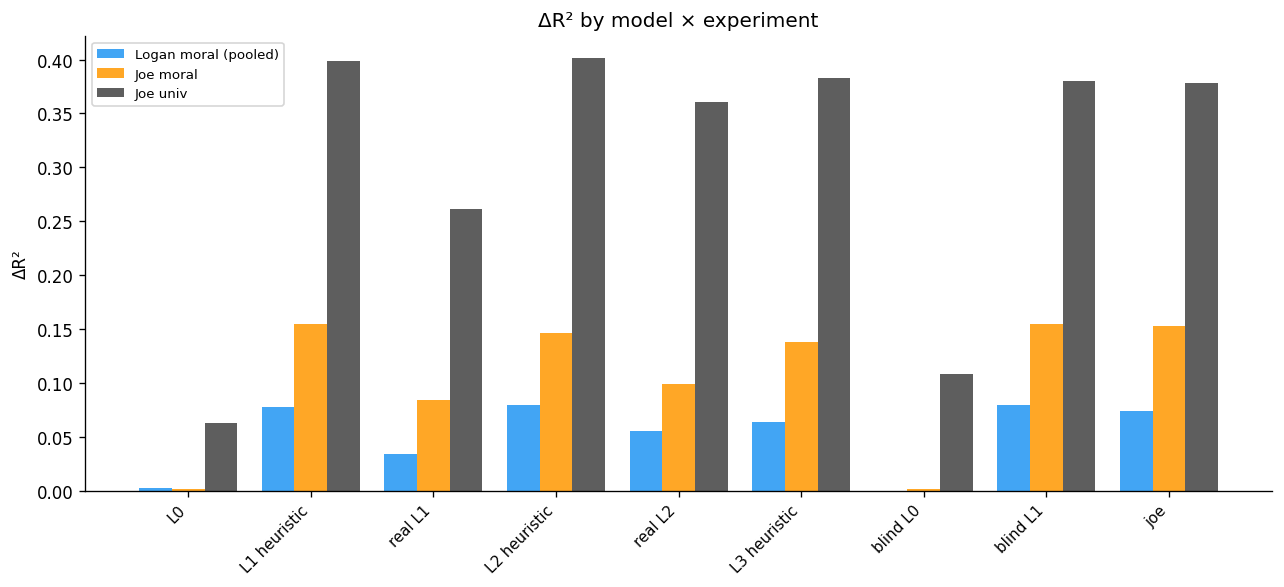

In [11]:
# Multi-experiment comparison

import matplotlib.pyplot as plt

eval_all = evaluate_fits_multi(dm, datasets)

keep_exps = ['Logan moral (pooled)', 'Joe moral', 'Joe univ']
eval_filtered = eval_all[eval_all['experiment'].isin(keep_exps)]


plot_eval_multi(eval_filtered, metric='delta_R2', run_order=RUN_ORDER,
                save_path='figures/delta_r2_baseline.png');


In [12]:
from new_comparison_utils import split_half_all
sh = split_half_all(datasets)
print(sh.to_string(index=False))

     name  n_participants  n_stimuli  r_half  ci_lo  ci_hi  spearman_brown  noise_ceiling
Joe moral              39         39  0.9680 0.9431 0.9825          0.9837         0.9918
 Joe univ              43         39  0.9615 0.9321 0.9800          0.9804         0.9901


# new 1. Grids

In [56]:
# Fixed order and colors for all figures
main_order = ['L0', 'L1 heuristic', 'L2 heuristic', 'L3 heuristic', 'real L1',
              'real L2']

full_order = main_order + ['joe', 'blind L0', 'blind L1']

main_colors = {
    'L0': '#CC4444',
    'L1 heuristic': '#2266CC',
    'L2 heuristic': '#B0C4DE',
    'L3 heuristic': '#B0C4DE',
    'real L1': '#2E8B57',
    'real L2': '#2E8B57',
    'joe': '#888780', 'blind L0': '#888780', 'blind L1': '#888780',
}

from bootstrap_significance import bootstrap_over_participants, bootstrap_delta_r2, test_hypotheses
from paper_figures import fig_level_depth_grid, fig_bootstrap_ci, fig_compute_time

my_grid_map = {
    'L0':                         (0, 0),
    'L1 heuristic':               (0, 1),
    'real L1':       (0, 2),
    'L2 heuristic':               (1, 1),
    'real L2':         (1, 2),
    'L3 heuristic':  (2, 1),
}


Saved to figures/grid_dr2_univ_new.png


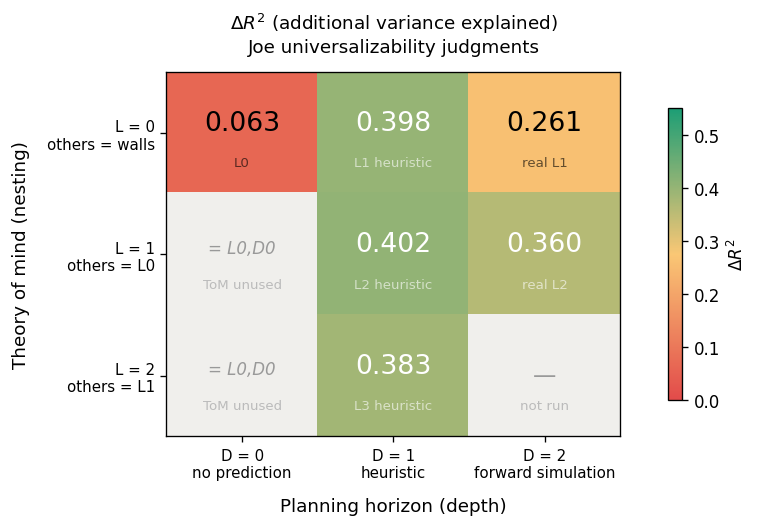

Saved to figures/grid_r_univ_new.png


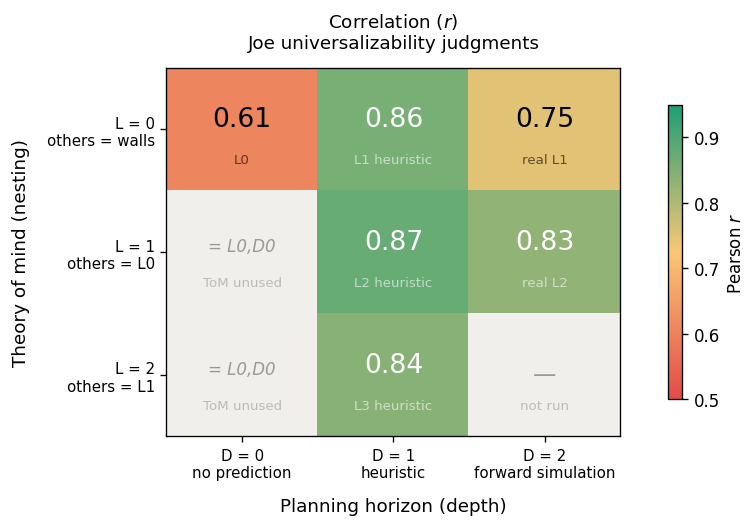

In [57]:
# Figure 1: grid (pulls from eval_df)
fig_level_depth_grid(eval_joe_univ, metric="delta_R2", grid_map=my_grid_map,
    title_suffix="Joe universalizability judgments",
    save_path="figures/grid_dr2_univ_new.png")

fig_level_depth_grid(eval_joe_univ, metric="r_U_AW", grid_map=my_grid_map,
    title_suffix="Joe universalizability judgments",
    save_path="figures/grid_r_univ_new.png")


Saved to figures/grid_dr2_moral.png


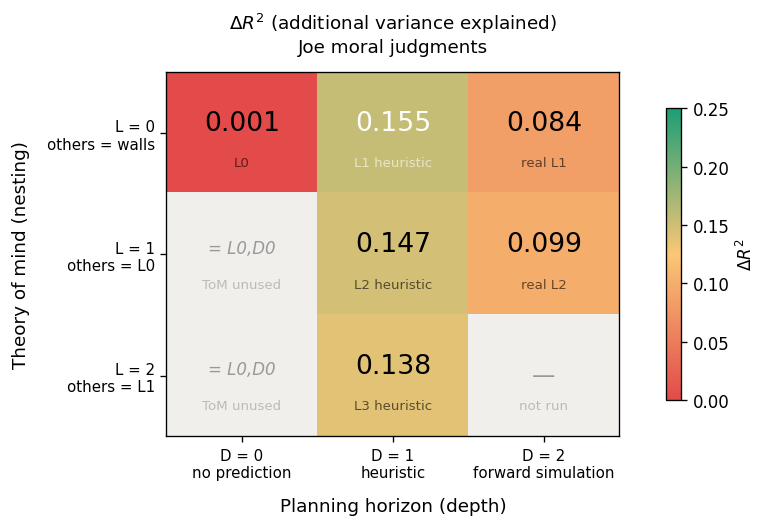

Saved to figures/grid_r_moral.png


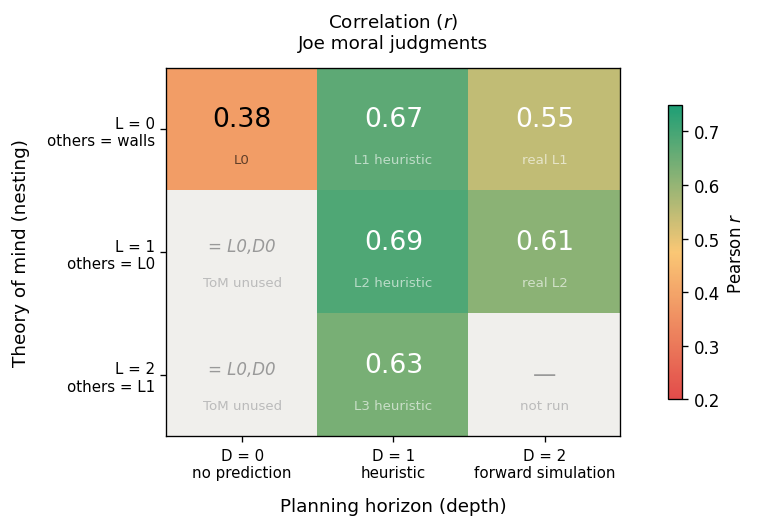

In [58]:
# Joe moral
fig_level_depth_grid(eval_joe_moral, metric="delta_R2", grid_map=my_grid_map,
    title_suffix="Joe moral judgments",
    save_path="figures/grid_dr2_moral.png")
fig_level_depth_grid(eval_joe_moral, metric="r_U_AW", grid_map=my_grid_map,
    title_suffix="Joe moral judgments",
    save_path="figures/grid_r_moral.png")

Saved to figures/grid_dr2_logan.png


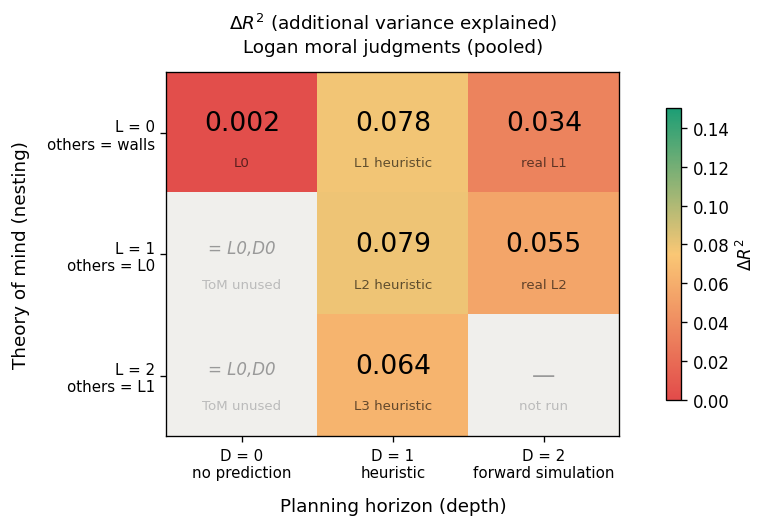

Saved to figures/grid_r_logan.png


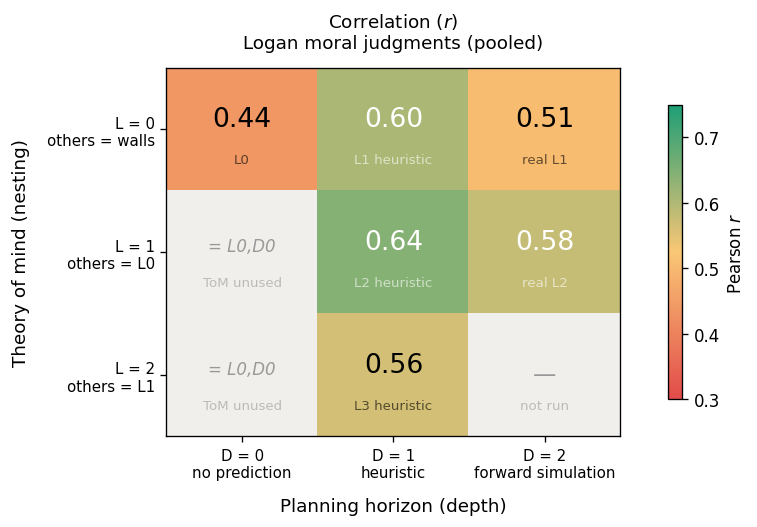

In [59]:


# Logan moral
fig_level_depth_grid(eval_logan, metric="delta_R2", grid_map=my_grid_map,
    title_suffix="Logan moral judgments (pooled)",
    save_path="figures/grid_dr2_logan.png")
fig_level_depth_grid(eval_logan, metric="r_U_AW", grid_map=my_grid_map,
    title_suffix="Logan moral judgments (pooled)",
    save_path="figures/grid_r_logan.png")

# new 2. Bootstraps

In [60]:
n_boot = 1000


Saved to figures/slide_2.png


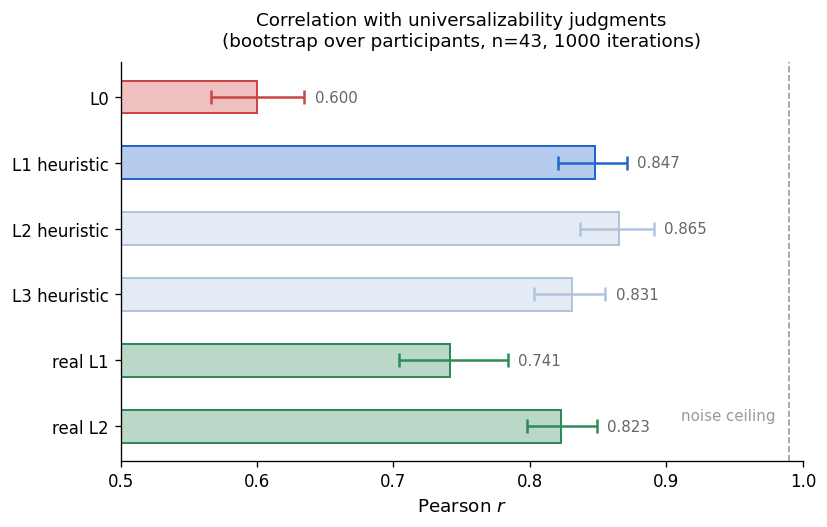

In [61]:

ci_r_univ, boot_r_univ = bootstrap_over_participants(dm["joe_univ"], datasets["joe_univ"], n_boot=n_boot)
fig_bootstrap_ci(boot_r_univ, model_order=main_order, colors=main_colors,
    xlabel='Pearson $r$',
    title='Correlation with universalizability judgments\n(bootstrap over participants, n=43, 1000 iterations)',  
    xlim=(0.5, 1.0), ceiling=0.9901,
    save_path="figures/slide_2.png")

=== Joe univ ΔR² ===
         tag  dr2_mean  dr2_median  dr2_ci_lo  dr2_ci_hi   dr2_se   r_mean  r_ci_lo  r_ci_hi
L2 heuristic  0.394097    0.394015   0.351494   0.440992 0.022518 0.865211 0.836962 0.890742
L1 heuristic  0.390699    0.390592   0.348924   0.433774 0.021600 0.847454 0.820626 0.871199
L3 heuristic  0.375738    0.375036   0.336566   0.415621 0.020941 0.830990 0.802837 0.855361
    blind L1  0.373127    0.373205   0.329361   0.415767 0.021798 0.828087 0.798271 0.853679
         joe  0.371163    0.370279   0.330477   0.411793 0.021117 0.809349 0.781162 0.835503
     real L2  0.353958    0.353492   0.312919   0.401316 0.022692 0.822812 0.798121 0.848934
     real L1  0.256553    0.255492   0.220940   0.302058 0.021261 0.741098 0.704354 0.783866
    blind L0  0.106264    0.106669   0.075276   0.136212 0.015479 0.531713 0.491568 0.569208
          L0  0.061620    0.061219   0.046174   0.081176 0.008720 0.600152 0.566377 0.634747
Saved to figures/dr2_joe_univ.png


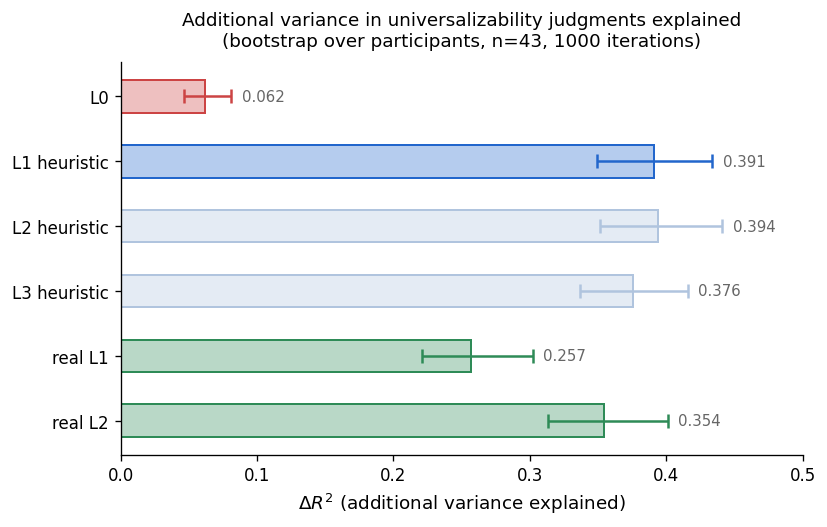

In [64]:
ci_dr2_univ, boot_dr2_univ = bootstrap_delta_r2(dm["joe_univ"], datasets["joe_univ"], n_boot=n_boot)
print("=== Joe univ ΔR² ===")
print(ci_dr2_univ.sort_values("dr2_mean", ascending=False).to_string(index=False))

fig_bootstrap_ci(boot_dr2_univ, model_order=main_order,
    xlabel='$\\Delta R^2$ (additional variance explained)',
    title='Additional variance in universalizability judgments explained\n(bootstrap over participants, n=43, 1000 iterations)',
                 colors=main_colors,
    xlim=(0, 0.5),
    save_path="figures/dr2_joe_univ.png")

=== Joe moral ΔR² ===
         tag  dr2_mean  dr2_median  dr2_ci_lo  dr2_ci_hi   dr2_se   r_mean  r_ci_lo  r_ci_hi
L1 heuristic  0.153568    0.153484   0.113557   0.193238 0.020377 0.663280 0.623581 0.695368
    blind L1  0.153093    0.152955   0.115228   0.190361 0.019562 0.647315 0.608627 0.677897
         joe  0.151232    0.151932   0.113505   0.189371 0.019639 0.617602 0.576422 0.651997
L2 heuristic  0.145349    0.145684   0.106078   0.184049 0.019433 0.681063 0.647081 0.708832
L3 heuristic  0.136936    0.137309   0.100818   0.174575 0.019159 0.628566 0.586049 0.662330
     real L2  0.098729    0.099268   0.065970   0.133264 0.016750 0.606262 0.567263 0.637927
     real L1  0.083992    0.084208   0.054147   0.114556 0.015483 0.540643 0.495842 0.578251
          L0  0.001878    0.001430   0.000044   0.006042 0.001650 0.379610 0.331686 0.416144
    blind L0  0.001785    0.001204   0.000007   0.006697 0.001827 0.230211 0.183698 0.269516
Saved to figures/dr2_joe_moral.png


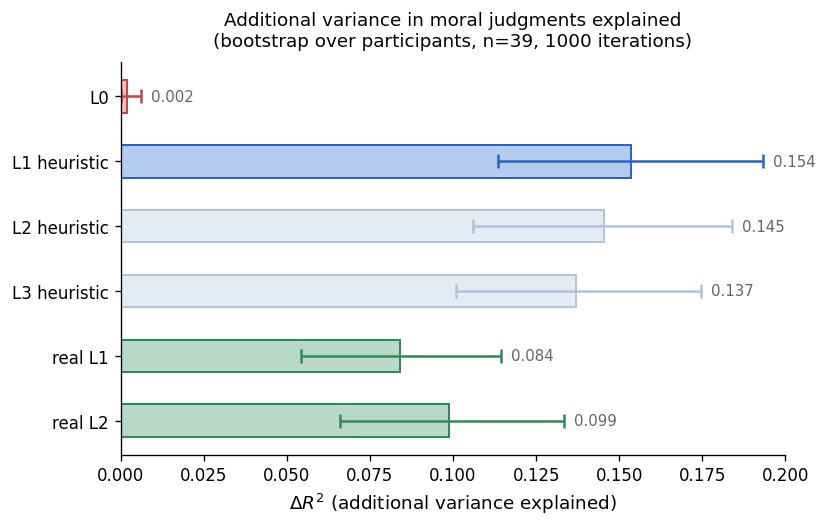

In [66]:
ci_dr2_moral, boot_dr2_moral = bootstrap_delta_r2(dm["joe_moral"], datasets["joe_moral"], n_boot=n_boot)
print("=== Joe moral ΔR² ===")
print(ci_dr2_moral.sort_values("dr2_mean", ascending=False).to_string(index=False))

fig_bootstrap_ci(boot_dr2_moral, model_order=main_order, 
    xlabel='$\\Delta R^2$ (additional variance explained)',
    title='Additional variance in moral judgments explained\n(bootstrap over participants, n=39, 1000 iterations)',
                 colors=main_colors,
    xlim=(0, 0.2),
    save_path="figures/dr2_joe_moral.png")

=== Joe moral r ===
         tag metric     mean   median    ci_lo    ci_hi       se
L2 heuristic      r 0.681063 0.681716 0.647081 0.708832 0.016253
L1 heuristic      r 0.663280 0.663892 0.623581 0.695368 0.018218
    blind L1      r 0.647315 0.647648 0.608627 0.677897 0.018245
L3 heuristic      r 0.628566 0.629443 0.586049 0.662330 0.020042
         joe      r 0.617602 0.617868 0.576422 0.651997 0.019820
     real L2      r 0.606262 0.606557 0.567263 0.637927 0.018235
     real L1      r 0.540643 0.540563 0.495842 0.578251 0.020409
          L0      r 0.379610 0.381287 0.331686 0.416144 0.021157
    blind L0      r 0.230211 0.229916 0.183698 0.269516 0.022157
Saved to figures/r_joe_moral_new.png


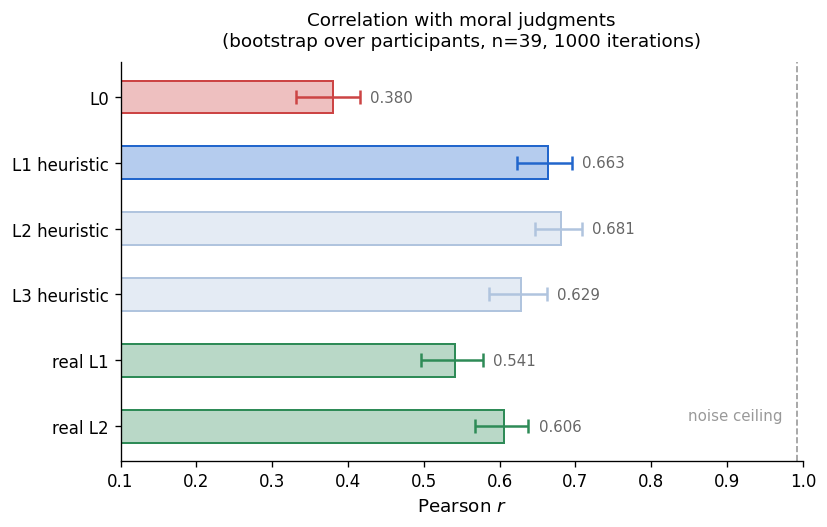

In [68]:
ci_r_moral, boot_r_moral = bootstrap_over_participants(dm["joe_moral"], datasets["joe_moral"], n_boot=n_boot)
print("=== Joe moral r ===")
print(ci_r_moral.sort_values("mean", ascending=False).to_string(index=False))

fig_bootstrap_ci(boot_r_moral, model_order=main_order, colors=main_colors,
    xlabel='Pearson $r$',
    title='Correlation with moral judgments\n(bootstrap over participants, n=39, 1000 iterations)',  
    xlim=(0.1, 1.0), ceiling=0.9918,
    save_path="figures/r_joe_moral_new.png")

# new 3. Computational cost (time)

Saved to figures/compute_time.png


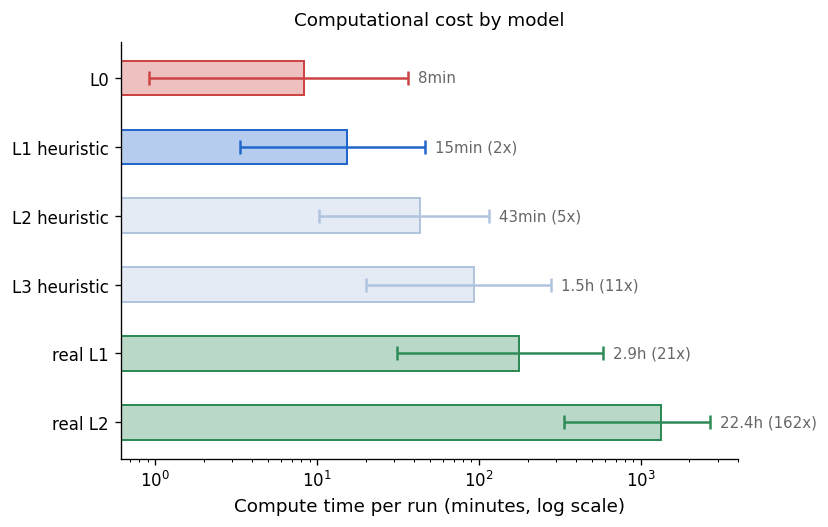

Saved to figures/compute_time_with_baselines.png


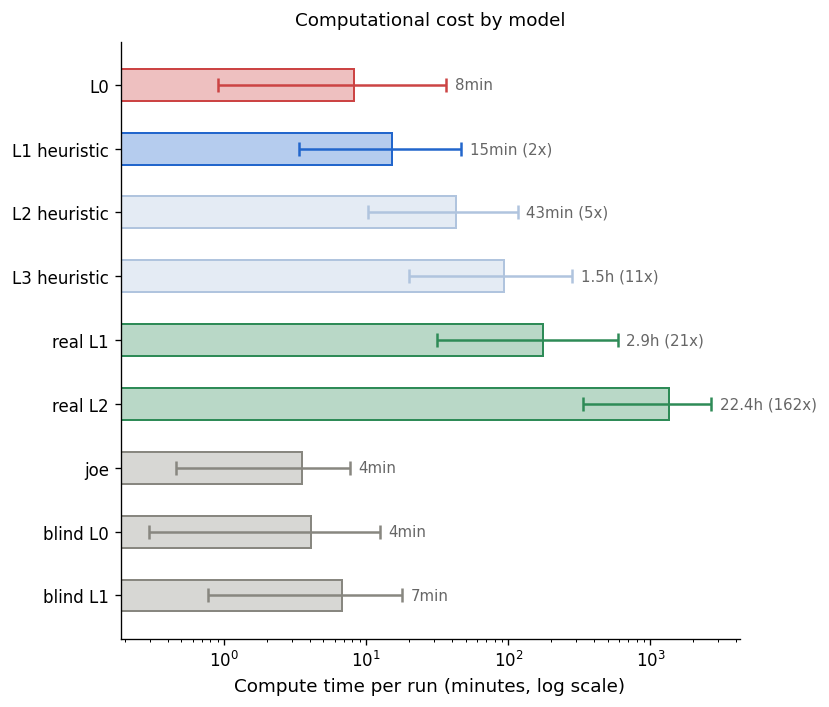

In [69]:
import os, glob

timing_detailed = {}
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        times = all_runs['run_elapsed_seconds'].values / 60  # minutes
        timing_detailed[tag] = times

fig_compute_time(timing_detailed, model_order=main_order, colors=main_colors,
    save_path='figures/compute_time.png')

fig_compute_time(timing_detailed, model_order=full_order, colors=main_colors,
    save_path='figures/compute_time_with_baselines.png')

In [70]:
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        agent_cols = [c for c in all_runs.columns if c.startswith('agent_')]
        n_stuck = (all_runs[agent_cols] <= 0).any(axis=1).sum()
        n_total = len(all_runs)
        print(f"{tag:30s}  {n_stuck}/{n_total}  ({100*n_stuck/n_total:.1f}%)")

L0                              1/140  (0.7%)
L1 heuristic                    0/140  (0.0%)
real L1                         15/140  (10.7%)
L2 heuristic                    0/140  (0.0%)
real L2                         1/130  (0.8%)
L3 heuristic                    0/140  (0.0%)
blind L0                        1/140  (0.7%)
blind L1                        0/140  (0.0%)
joe                             0/140  (0.0%)


# New 4. Per map scatter plots

In [ ]:
from paper_figures import fig_model_vs_humans, fig_model_vs_model

tags = ['L0', 'L1 heuristic', 'real L1']

# Macro level, label maps with U_AW < -10
fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
    tags=tags,
    colors=main_colors, detail_level='macro', label_threshold=None,
    save_path='figures/model_vs_humans_macro.png')

# Sub level
#fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
 #   tags=['L0', 'L1 heuristic', 'real L1'],
  #  colors=main_colors, detail_level='sub', label_threshold=-10,
   # save_path='figures/model_vs_humans_sub.png')

# Trimmed to see the main cluster better
#fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
 #   tags=['L0', 'L1 heuristic', 'real L1'],
  #  colors=main_colors, detail_level='macro',
   # xlim=(-8, 4), ylim=(0, 100),
    #save_path='figures/model_vs_humans_trimmed.png')

# Print maps with very low U_AW per model
for tag in tags:
    dm_tag = dm['joe_univ'][tag]
    low = dm_tag[dm_tag['univ_aggregate_welfare'] < -5][['stimulus', 'univ_aggregate_welfare']]
    if len(low) > 0:
        print(f"\n{tag} — maps with U_AW < -10:")
        print(low.sort_values('univ_aggregate_welfare').to_string(index=False))
    else:
        print(f"\n{tag} — no maps with U_AW < -10")

Saved to figures/scatter_L0_vs_L1h.png


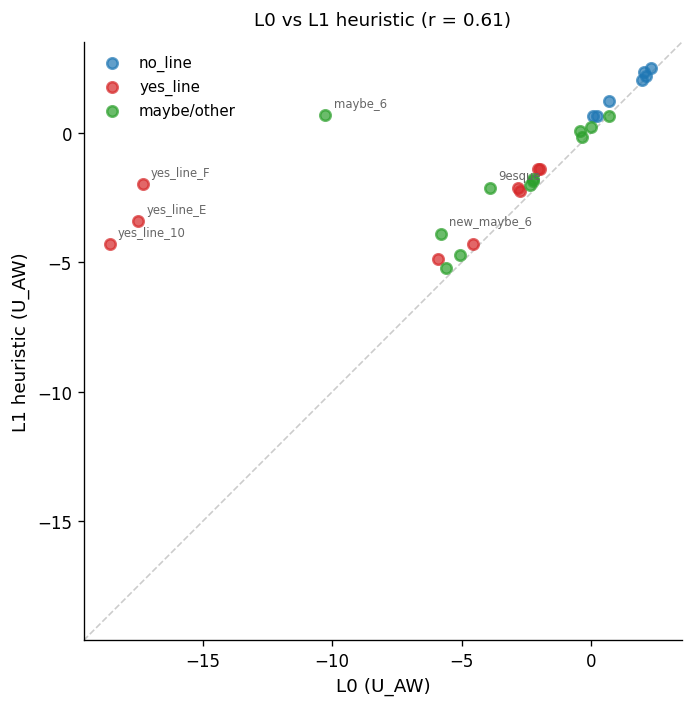

In [43]:
fig_model_vs_model(sims, 'L0', 'L1 heuristic',
    detail_level='macro',
    save_path='figures/scatter_L0_vs_L1h.png')


Saved to figures/scatter_L1h_vs_realL1.png


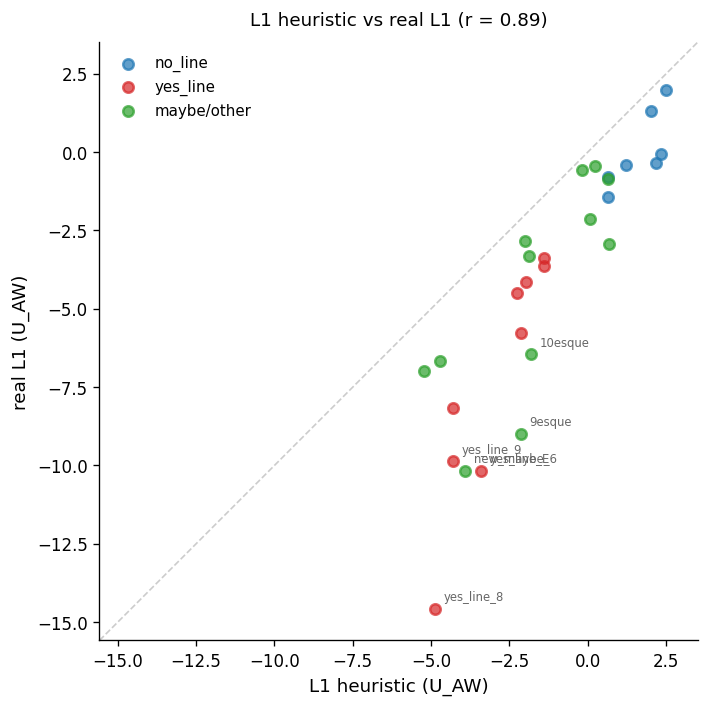

In [46]:
fig_model_vs_model(sims, 'L1 heuristic', 'real L1',
    detail_level='macro',
    save_path='figures/scatter_L1h_vs_realL1.png')


Saved to figures/scatter_L1h_vs_realL2.png


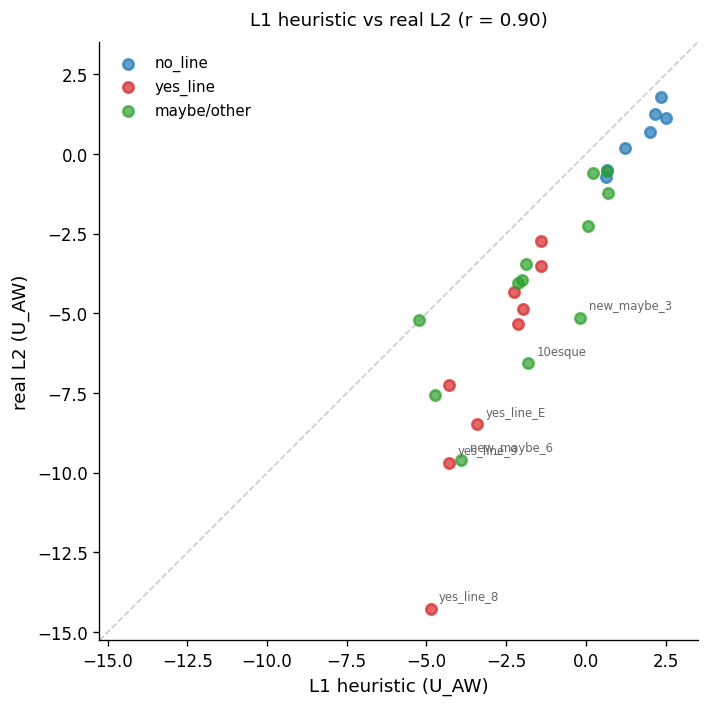

In [47]:
fig_model_vs_model(sims, 'L1 heuristic', 'real L2',
    detail_level='macro',
    save_path='figures/scatter_L1h_vs_realL2.png')


Saved to figures/scatter_realL1_vs_realL2.png


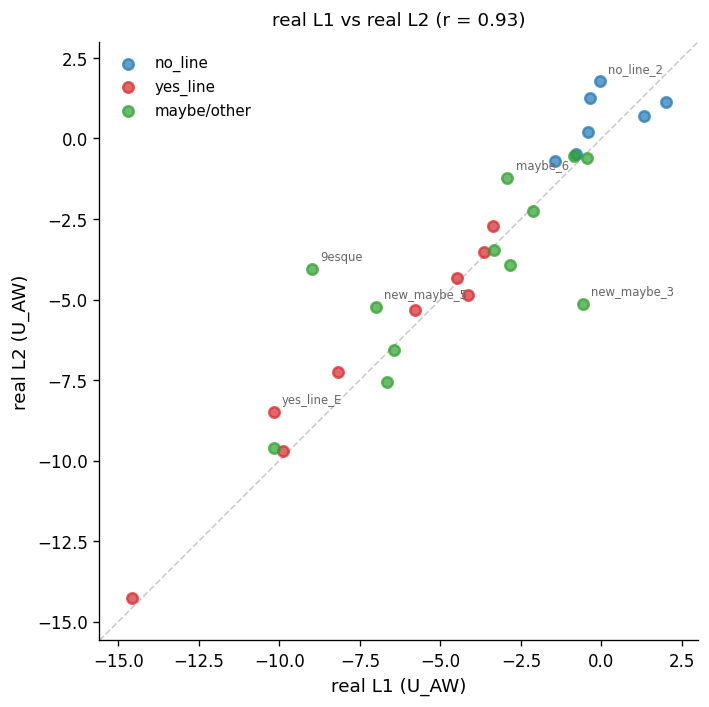

In [49]:
fig_model_vs_model(sims, 'real L1', 'real L2',
    detail_level='macro',
    save_path='figures/scatter_realL1_vs_realL2.png')


Saved to figures/model_vs_humans_macro_l2.png


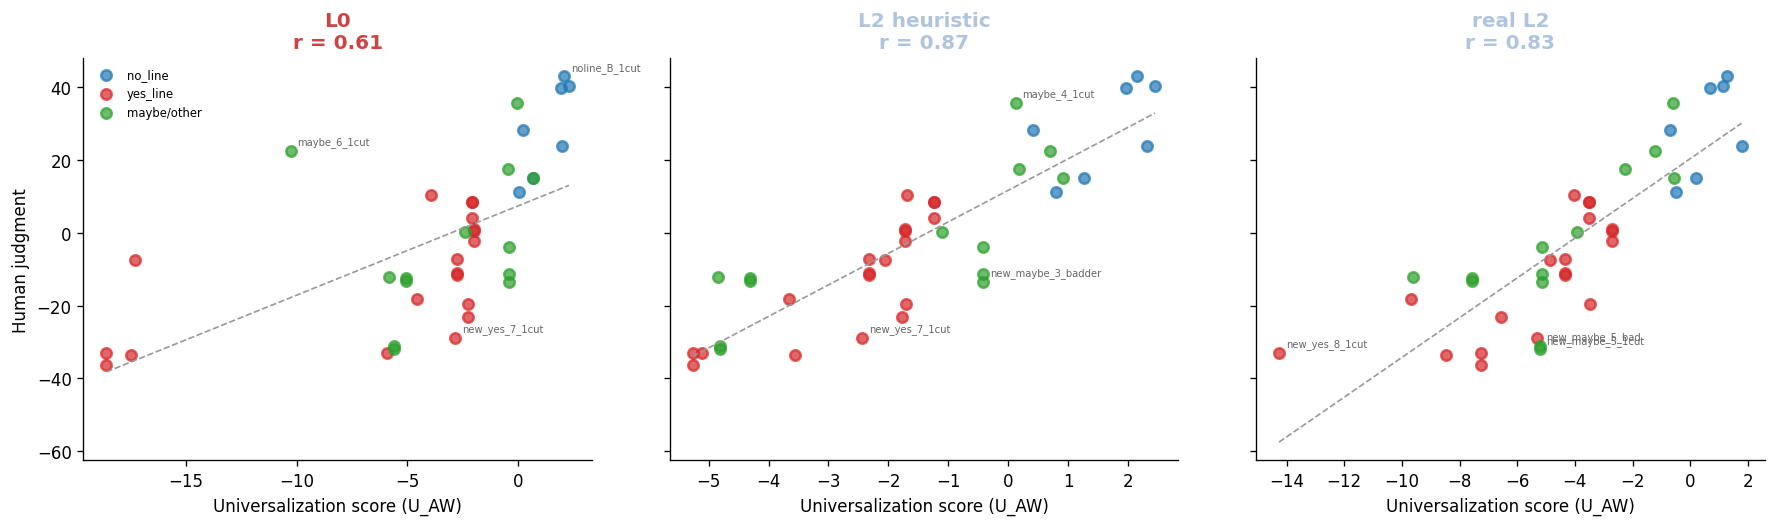


L0 — maps with U_AW < -10:
        stimulus  univ_aggregate_welfare
  new_yes_10_bad              -18.594805
 new_yes_10_1cut              -18.594805
  yesline_E_1cut              -17.491935
  yesline_F_1cut              -17.321569
    maybe_6_1cut              -10.266667
  new_yes_8_1cut               -5.913793
new_maybe_6_1cut               -5.816667
 new_maybe_5_bad               -5.613208
new_maybe_5_1cut               -5.613208
 new_maybe_4_bad               -5.050000
new_maybe_4_1cut               -5.050000

L2 heuristic — maps with U_AW < -10:
       stimulus  univ_aggregate_welfare
 new_yes_10_bad               -5.264935
new_yes_10_1cut               -5.264935
 new_yes_8_1cut               -5.113793

real L2 — maps with U_AW < -10:
          stimulus  univ_aggregate_welfare
    new_yes_8_1cut              -14.258621
    new_yes_9_1cut               -9.690323
  new_maybe_6_1cut               -9.604167
    yesline_E_1cut               -8.477419
   new_maybe_4_bad               -

In [42]:

tags = ['L0', 'L2 heuristic', 'real L2']

# Macro level, label maps with U_AW < -10
fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
    tags=tags,
    colors=main_colors, detail_level='macro', label_threshold=None,
    save_path='figures/model_vs_humans_macro_l2.png')

# Sub level
#fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
 #   tags=['L0', 'L1 heuristic', 'real L1'],
  #  colors=main_colors, detail_level='sub', label_threshold=-10,
   # save_path='figures/model_vs_humans_sub.png')

# Trimmed to see the main cluster better
#fig_model_vs_humans(dm['joe_univ'], datasets['joe_univ'],
 #   tags=['L0', 'L1 heuristic', 'real L1'],
  #  colors=main_colors, detail_level='macro',
   # xlim=(-8, 4), ylim=(0, 100),
    #save_path='figures/model_vs_humans_trimmed.png')

# Print maps with very low U_AW per model
for tag in tags:
    dm_tag = dm['joe_univ'][tag]
    low = dm_tag[dm_tag['univ_aggregate_welfare'] < -5][['stimulus', 'univ_aggregate_welfare']]
    if len(low) > 0:
        print(f"\n{tag} — maps with U_AW < -10:")
        print(low.sort_values('univ_aggregate_welfare').to_string(index=False))
    else:
        print(f"\n{tag} — no maps with U_AW < -10")

# new 5. Other / garbage

In [31]:
# Point estimate from eval
print("Grid values:", eval_joe_univ[['tag', 'r_U_AW']].to_string(index=False))

# Bootstrap means
print("\nBootstrap means:")
for tag in slide2_order:
    if tag in boot_r_univ:
        print(f"  {tag:30s}  {np.mean(boot_r_univ[tag]):.4f}")

Grid values:          tag   r_U_AW
L2 heuristic 0.873878
L1 heuristic 0.855906
L3 heuristic 0.839324
    blind L1 0.836494
         joe 0.817354
     real L2 0.830792
     real L1 0.748248
    blind L0 0.536573
          L0 0.606324

Bootstrap means:


NameError: name 'slide2_order' is not defined

In [32]:
from bootstrap_significance import bootstrap_pairwise

contrasts = [
    ('L1 heuristic', 'L0',             'L1 heuristic vs L0 (does reasoning help?)'),
    ('real L1',       'L1 heuristic',   'Real L1 vs L1 heuristic (does depth help?)'),
    ('L2 heuristic',  'L1 heuristic',   'L2 heuristic vs L1 heuristic (does ToM help?)'),
    ('L3 heuristic',  'L2 heuristic',   'L3 heuristic vs L2 heuristic (more ToM?)'),
    ('real L2', 'L1 heuristic', 'Real L2 vs L1 heuristic (both ToM+depth?)'),
]

mats = dm["joe_univ"]
exp = datasets["joe_univ"]

for better, base, desc in contrasts:
    res = bootstrap_pairwise(mats, exp, better, base, metric="delta_r2", n_boot=1000)
    sig = "***" if res['p_value'] < 0.001 else "**" if res['p_value'] < 0.01 else "*" if res['p_value'] < 0.05 else "n.s."
    arrow = "↑" if res['diff_mean'] > 0 else "↓"
    print(f"{desc}")
    print(f"  ΔΔR² = {res['diff_mean']:+.4f}  [{res['ci_lo']:+.4f}, {res['ci_hi']:+.4f}]  p={res['p_value']:.3f} {sig} {arrow}")
    print()

L1 heuristic vs L0 (does reasoning help?)
  ΔΔR² = +0.3291  [+0.2932, +0.3642]  p=0.000 *** ↑

Real L1 vs L1 heuristic (does depth help?)
  ΔΔR² = -0.1341  [-0.1616, -0.1010]  p=1.000 n.s. ↓

L2 heuristic vs L1 heuristic (does ToM help?)
  ΔΔR² = +0.0034  [-0.0047, +0.0123]  p=0.215 n.s. ↑

L3 heuristic vs L2 heuristic (more ToM?)
  ΔΔR² = -0.0184  [-0.0326, -0.0038]  p=0.998 n.s. ↓

Real L2 vs L1 heuristic (both ToM+depth?)
  ΔΔR² = -0.0367  [-0.0660, -0.0081]  p=0.987 n.s. ↓



In [33]:
# Clean regression summary table
for eval_df, name in [(eval_joe_univ, "Joe univ"), (eval_joe_moral, "Joe moral")]:
    print(f"\n=== {name} ===")
    cols = ['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'se_U_AW', 'p_U_AW', 'delta_BIC']
    print(eval_df[cols].round(4).to_string(index=False))


=== Joe univ ===
         tag  r_U_AW  delta_R2  beta_U_AW  se_U_AW  p_U_AW  delta_BIC
L2 heuristic  0.8739    0.4018     7.4698   0.8965  0.0000   -39.7219
L1 heuristic  0.8559    0.3983     7.2561   0.8825  0.0000   -39.0324
L3 heuristic  0.8393    0.3832     6.7912   0.8734  0.0000   -36.1899
    blind L1  0.8365    0.3806     7.0112   0.9100  0.0000   -35.7287
         joe  0.8174    0.3783     6.7233   0.8798  0.0000   -35.3244
     real L2  0.8308    0.3604     4.5407   0.6330  0.0000   -32.2786
     real L1  0.7482    0.2613     3.6928   0.7195  0.0000   -18.7080
    blind L0  0.5366    0.1078     1.8436   0.6744  0.0099    -4.0841
          L0  0.6063    0.0629     1.4229   0.7121  0.0538    -0.6664

=== Joe moral ===
         tag  r_U_AW  delta_R2  beta_U_AW  se_U_AW  p_U_AW  delta_BIC
L1 heuristic  0.6688    0.1549     5.1068   1.2078  0.0002   -12.8144
    blind L1  0.6528    0.1545     5.0420   1.1946  0.0002   -12.7664
         joe  0.6228    0.1527     4.8209   1.1525  0

In [34]:
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        agent_cols = [c for c in all_runs.columns if c.startswith('agent_')]
        n_stuck = (all_runs[agent_cols] <= 0).any(axis=1).sum()
        n_total = len(all_runs)
        print(f"{tag:30s}  {n_stuck}/{n_total} ({100*n_stuck/n_total:.1f}%)")

L0                              1/140 (0.7%)
L1 heuristic                    0/140 (0.0%)
real L1                         15/140 (10.7%)
L2 heuristic                    0/140 (0.0%)
real L2                         1/130 (0.8%)
L3 heuristic                    0/140 (0.0%)
blind L0                        1/140 (0.7%)
blind L1                        0/140 (0.0%)
joe                             0/140 (0.0%)


In [35]:
dm_tag = dm['joe_univ']['L0']
print(dm_tag['stimulus'].unique())

['maybe_4_1cut' 'maybe_5_1cut' 'maybe_6_1cut' 'new_maybe_3_bad'
 'new_maybe_3_badder' 'new_maybe_4_bad' 'new_maybe_5_bad'
 'new_maybe_1_1cut' 'new_maybe_2_1cut' 'new_maybe_3_1cut'
 'new_maybe_4_1cut' 'new_maybe_5_1cut' 'new_maybe_6_1cut'
 'new_yes_10mod_1cut' 'new_yes_7esque_1cut' 'new_yes_9esque_1cut'
 'new_no_1_1cut' 'new_no_2_1cut' 'new_no_3_1cut' 'noline_A_1cut'
 'noline_B_1cut' 'noline_C_1cut' 'noline_D_1cut' 'new_yes_7_1cut'
 'new_yes_10_bad' 'new_yes_8_1cut' 'new_yes_9_1cut' 'new_yes_10_1cut'
 'yesline_B_1cut' 'yesline_B_bad' 'yesline_B_badder' 'yesline_C_1cut'
 'yesline_C_bad' 'yesline_C_badder' 'yesline_D_1cut' 'yesline_D_bad'
 'yesline_D_badder' 'yesline_E_1cut' 'yesline_F_1cut']


In [36]:
for tag in ['L0', 'L1 heuristic', 'real L1']:
    dm_tag = dm['joe_univ'][tag]
    print(f"{tag:20s}  mean inequality = {dm_tag['univ_inequality'].mean():.3f}")
    # Also check the bad maps
    bad = dm_tag[dm_tag['univ_aggregate_welfare'] < -6]
    if len(bad) > 0:
        print(f"  {'':20s}  bad maps: mean inequality = {bad['univ_inequality'].mean():.3f}")


for tag in ['L0', 'L1 heuristic', 'real L1']:
    label = RUNS[tag]
    f = f"../data/simulations/{label}/raw/yes_line_8.csv"
    if os.path.exists(f):
        df = pd.read_csv(f)
        agent_cols = [c for c in df.columns if c.startswith('agent_')]
        print(f"\n{tag} — yes_line_8:")
        print(df[agent_cols].to_string(index=False))

L0                    mean inequality = 0.878
                        bad maps: mean inequality = 3.665
L1 heuristic          mean inequality = 0.364
real L1               mean inequality = 1.093
                        bad maps: mean inequality = 1.792

L0 — yes_line_8:
 agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
      29       31       97      131      112       69       81      142
      36       54       70       87       62       97      126      116
      28       37       70       62      137       90      109      117
      48       43       65      112       83      108       55      123
      39       51      132       99       76      117       77      152

L1 heuristic — yes_line_8:
 agent_1  agent_2  agent_3  agent_4  agent_5  agent_6  agent_7  agent_8
      28       39       62       46       86      106      107       81
      49       41       96       82      112       53       71      121
      32       54       43      101       61      12

In [37]:
# Compare maps where real L1 has 0% stuck/fallback vs maps where it doesn't
for tag in ['L1 heuristic', 'real L1']:
    dm_tag = dm['joe_univ'][tag]
    print(f"\n{tag}:")
    print(f"  mean U_AW = {dm_tag['univ_aggregate_welfare'].mean():.3f}")
    print(f"  median U_AW = {dm_tag['univ_aggregate_welfare'].median():.3f}")


L1 heuristic:
  mean U_AW = -1.524
  median U_AW = -1.405

real L1:
  mean U_AW = -4.161
  median U_AW = -3.644


In [38]:
# Check: is real L1 using the same depth-1 view as L1 heuristic?
# Compare their outputs on a simple map where both should agree
for tag in ['L1 heuristic', 'real L1']:
    label = RUNS[tag]
    f = f"../data/simulations/{label}/raw/no_line_1.csv"
    if os.path.exists(f):
        df = pd.read_csv(f)
        agent_cols = [c for c in df.columns if c.startswith('agent_')]
        totals = df[agent_cols].sum(axis=1).tolist()
        print(f"{tag:20s}  no_line_1 totals: {totals}")

L1 heuristic          no_line_1 totals: [194, 190, 197, 192, 192]
real L1               no_line_1 totals: [259, 275, 250, 281, -8]


In [14]:
import os
import pandas as pd
from pathlib import Path

def merge_split_runs(run_prefix, sim_root="../data/simulations", output_label=None):
    """
    Merge single-run directories (run0, run1, ...) into one multi-run directory.
    
    Finds directories matching run_prefix*, picks the one with most maps per run number,
    concatenates CSVs by map name, renumbers the 'run' column.
    """
    sim_root = Path(sim_root)
    
    # Find all directories matching prefix
    all_dirs = sorted(sim_root.glob(f"{run_prefix}*"))
    
    # Group by run number (extract from directory name)
    run_dirs = {}
    for d in all_dirs:
        name = d.name
        # Extract run number from e.g. "real_L2_run0_2026-04-24_231639"
        for part in name.split('_'):
            if part.startswith('run') and part[3:].isdigit():
                run_num = int(part[3:])
                raw_dir = d / "raw"
                if raw_dir.exists():
                    n_maps = len(list(raw_dir.glob("*.csv")))
                    if n_maps > 0:
                        # Keep the directory with most maps for this run number
                        if run_num not in run_dirs or n_maps > run_dirs[run_num][1]:
                            run_dirs[run_num] = (raw_dir, n_maps)
                break
    
    print(f"Found {len(run_dirs)} runs:")
    for run_num in sorted(run_dirs):
        raw_dir, n_maps = run_dirs[run_num]
        print(f"  run {run_num}: {n_maps} maps from {raw_dir.parent.name}")
    
    # Collect all map names across all runs
    all_maps = set()
    for raw_dir, _ in run_dirs.values():
        for f in raw_dir.glob("*.csv"):
            all_maps.add(f.stem)
    
    # Create output directory
    if output_label is None:
        output_label = run_prefix + "_merged"
    output_dir = sim_root / output_label / "raw"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Merge each map
    for map_name in sorted(all_maps):
        frames = []
        for run_num in sorted(run_dirs):
            raw_dir, _ = run_dirs[run_num]
            f = raw_dir / f"{map_name}.csv"
            if f.exists():
                df = pd.read_csv(f)
                df['run'] = run_num + 1  # renumber 1-5
                frames.append(df)
        
        if frames:
            merged = pd.concat(frames, ignore_index=True)
            merged.to_csv(output_dir / f"{map_name}.csv", index=False)
    
    n_maps = len(list(output_dir.glob("*.csv")))
    first_csv = next(output_dir.glob("*.csv"))
    n_runs = len(pd.read_csv(first_csv))
    print(f"\nMerged into {output_label}: {n_maps} maps, {n_runs} runs each")
    print(f"Saved to {output_dir}")

# Usage for real L2:
merge_split_runs("real_L2_run", output_label="real_L2_merged")

# Also works for real L1 fills if needed:
# merge_split_runs("real_L1_run", output_label="real_L1_fill_merged")

Found 5 runs:
  run 0: 24 maps from real_L2_run0_2026-04-24_231739
  run 1: 26 maps from real_L2_run1_2026-04-25_000038
  run 2: 28 maps from real_L2_run2_2026-04-24_231739
  run 3: 26 maps from real_L2_run3_2026-04-24_231739
  run 4: 26 maps from real_L2_run4_2026-04-24_231739

Merged into real_L2_merged: 28 maps, 5 runs each
Saved to ../data/simulations/real_L2_merged/raw


In [ ]:
# then do 
'real L2': 'real_L2_merged',

In [ ]:
# After merging, check coverage
for f in sorted(Path("../data/simulations/real_L2_merged/raw").glob("*.csv")):
    df = pd.read_csv(f)
    print(f"{f.stem:20s}  {len(df)} runs")

In [27]:
import os, glob
import pandas as pd

# Pull elapsed times from raw CSVs
timing = {}
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        timing[tag] = {
            'mean_per_run': all_runs['run_elapsed_seconds'].mean(),
            'median_per_run': all_runs['run_elapsed_seconds'].median(),
            'total': all_runs['run_elapsed_seconds'].sum(),
            'n_maps': len(csvs),
            'n_runs': len(all_runs) // len(csvs),
        }

timing_df = pd.DataFrame(timing).T
timing_df['mean_per_run_min'] = timing_df['mean_per_run'] / 60
timing_df = timing_df.sort_values('mean_per_run')
print(timing_df[['n_maps', 'n_runs', 'mean_per_run_min']].round(1).to_string())

                           n_maps  n_runs  mean_per_run_min
joe                          28.0     5.0               3.5
blind L0                     28.0     5.0               4.1
blind L1                     28.0     5.0               6.7
L0 (1 run only)              28.0     1.0               6.9
L0                           28.0     5.0               8.3
L1 heuristic                 28.0     5.0              15.3
L1 heuristic (1 run only)    28.0     1.0              31.4
L2 heuristic                 28.0     5.0              43.2
depth2_v2                    28.0     5.0              64.7
L3 heuristic                 28.0     5.0              92.9
depth2_v1                    28.0     5.0             104.2
real L1 (27/28 maps)         28.0     4.0             177.1
real L1 (1 run only)         28.0     1.0             309.5
real L2 (1/5 runs)           28.0     1.0             617.7


In [52]:
stuck_rates = {}
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        agent_cols = [c for c in all_runs.columns if c.startswith('agent_')]
        n_stuck = (all_runs[agent_cols] <= 0).any(axis=1).sum()
        stuck_rates[tag] = 100 * n_stuck / len(all_runs)

for t in my_order:
    if t in stuck_rates and stuck_rates[t] > 0:
        print(f"{t:30s}  {stuck_rates[t]:.1f}% stuck")

L0                              0.7% stuck
blind L0                        0.7% stuck


L0 (1 run only)                 0/28  (0.0%)
L0                              1/140  (0.7%)
L1 heuristic (1 run only)       0/28  (0.0%)
L1 heuristic                    0/140  (0.0%)
real L1 (1 run only)            3/28  (10.7%)
real L1                         15/140  (10.7%)
L2 heuristic                    0/140  (0.0%)
real L2 (1/5 runs)              0/28  (0.0%)
L3 heuristic                    0/140  (0.0%)
blind L0                        1/140  (0.7%)
blind L1                        0/140  (0.0%)
joe                             0/140  (0.0%)
depth2_v1                       1/140  (0.7%)
depth2_v2                       0/140  (0.0%)


In [31]:
# Check simulation noise
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        first = pd.read_csv(csvs[0])
        n_runs = len(first)
        if n_runs > 1:
            # Compute mean agent score per run, get SD across runs
            agent_cols = [c for c in first.columns if c.startswith('agent_')]
            first['total'] = first[agent_cols].sum(axis=1)
            print(f"{tag:30s}  {n_runs} runs  SD={first['total'].std():.1f}  mean={first['total'].mean():.1f}")

L0                              5 runs  SD=19.9  mean=326.2
L1 heuristic                    5 runs  SD=26.9  mean=314.2
real L1 (27/28 maps)            5 runs  SD=204.8  mean=396.2
L2 heuristic                    5 runs  SD=25.5  mean=328.4
L3 heuristic                    5 runs  SD=14.0  mean=312.0
blind L0                        5 runs  SD=20.0  mean=334.8
blind L1                        5 runs  SD=17.8  mean=300.4
joe                             5 runs  SD=22.1  mean=293.8
depth2_v1                       5 runs  SD=40.6  mean=321.6
depth2_v2                       5 runs  SD=13.2  mean=311.6


In [32]:
label = RUNS['real L1 (27/28 maps)']
raw_dir = os.path.join("../data/simulations", label, "raw")
csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
for f in csvs:
    df = pd.read_csv(f)
    agent_cols = [c for c in df.columns if c.startswith('agent_')]
    df['total'] = df[agent_cols].sum(axis=1)
    sd = df['total'].std()
    mean = df['total'].mean()
    if sd > 50 or mean > 500:
        print(f"{os.path.basename(f):20s}  mean={mean:.0f}  SD={sd:.0f}  vals={df['total'].tolist()}")

new_maybe_3.csv       mean=396  SD=205  vals=[338, 261, 240, 397, 745]
no_line_1.csv         mean=211  SD=123  vals=[259, 275, 250, 281, -8]
no_line_3.csv         mean=219  SD=69  vals=[149, 225, 149, 299, 274]
no_line_D.csv         mean=237  SD=57  vals=[245, 209, 330, 224, 179]
no_line_2.csv         mean=192  SD=94  vals=[156, 240, 54, 204, 304]
new_maybe_5.csv       mean=1286  SD=109  vals=[1420, 1282, 1254, 1345, 1129]
new_maybe_4.csv       mean=709  SD=79  vals=[760, 649, 803, 610, 721]
new_maybe_6.csv       mean=807  SD=86  vals=[723, 766, 801, 950, 793]
no_line_B.csv         mean=273  SD=134  vals=[249, 188, 504, 171, 251]
yes_line_B.csv        mean=665  SD=80  vals=[626, 579, 749, 619, 753]
yes_line_7.csv        mean=508  SD=55  vals=[447, 540, 531, 569, 452]
yes_line_D.csv        mean=350  SD=93  vals=[389, 365, 358, 194, 442]
yes_line_E.csv        mean=1015  SD=60  vals=[995, 1070, 1076, 931, 1001]
yes_line_F.csv        mean=507  SD=126  vals=[537, 568, 374, 671, 387]
10esque

In [33]:
label_h = RUNS['L1 heuristic']
raw_dir_h = os.path.join("../data/simulations", label_h, "raw")
for mapname in ['9esque', 'yes_line_8', 'new_maybe_3', 'no_line_1', 'maybe_6']:
    f = os.path.join(raw_dir_h, f"{mapname}.csv")
    if os.path.exists(f):
        df = pd.read_csv(f)
        agent_cols = [c for c in df.columns if c.startswith('agent_')]
        df['total'] = df[agent_cols].sum(axis=1)
        print(f"{mapname:20s}  mean={df['total'].mean():.0f}  SD={df['total'].std():.0f}  vals={df['total'].tolist()}")

9esque                mean=350  SD=27  vals=[313, 349, 358, 387, 343]
yes_line_8            mean=613  SD=67  vals=[555, 625, 590, 723, 573]
new_maybe_3           mean=314  SD=27  vals=[299, 302, 292, 319, 359]
no_line_1             mean=193  SD=3  vals=[194, 190, 197, 192, 192]
maybe_6               mean=261  SD=13  vals=[265, 270, 241, 255, 275]


In [34]:
for mapname in ['9esque', 'yes_line_8', 'new_maybe_3', 'no_line_1']:
    print(f"\n=== {mapname} ===")
    for tag in ['L0', 'L1 heuristic', 'real L1 (27/28 maps)', 'L2 heuristic']:
        label = RUNS[tag]
        f = os.path.join("../data/simulations", label, "raw", f"{mapname}.csv")
        if os.path.exists(f):
            df = pd.read_csv(f)
            agent_cols = [c for c in df.columns if c.startswith('agent_')]
            df['total'] = df[agent_cols].sum(axis=1)
            print(f"  {tag:30s}  mean={df['total'].mean():.0f}  SD={df['total'].std():.0f}  vals={df['total'].tolist()}")


=== 9esque ===
  L0                              mean=436  SD=241  vals=[339, 301, 340, 333, 867]
  L1 heuristic                    mean=350  SD=27  vals=[313, 349, 358, 387, 343]
  real L1 (27/28 maps)            mean=680  SD=293  vals=[728, 428, 741, 387, 1114]
  L2 heuristic                    mean=329  SD=35  vals=[318, 363, 342, 274, 350]

=== yes_line_8 ===
  L0                              mean=674  SD=44  vals=[692, 648, 650, 637, 743]
  L1 heuristic                    mean=613  SD=67  vals=[555, 625, 590, 723, 573]
  real L1 (27/28 maps)            mean=1177  SD=216  vals=[1148, 929, 1022, 1451, 1334]
  L2 heuristic                    mean=628  SD=90  vals=[607, 576, 783, 555, 617]

=== new_maybe_3 ===
  L0                              mean=326  SD=20  vals=[311, 319, 318, 322, 361]
  L1 heuristic                    mean=314  SD=27  vals=[299, 302, 292, 319, 359]
  real L1 (27/28 maps)            mean=396  SD=205  vals=[338, 261, 240, 397, 745]
  L2 heuristic                 

In [35]:
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        all_runs = pd.concat([pd.read_csv(f) for f in csvs])
        agent_cols = [c for c in all_runs.columns if c.startswith('agent_')]
        n_neg = (all_runs[agent_cols] < 0).any(axis=1).sum()
        n_total = len(all_runs)
        if n_neg > 0:
            print(f"{tag:30s}  {n_neg}/{n_total} runs have stuck agents")

L0                              1/140 runs have stuck agents
real L1 (1 run only)            3/28 runs have stuck agents
real L1 (27/28 maps)            15/136 runs have stuck agents
blind L0                        1/140 runs have stuck agents
depth2_v1                       1/140 runs have stuck agents


In [14]:
from bootstrap_significance import bootstrap_over_participants, pairwise_comparison_table

# For Joe univ:
exp = datasets["joe_univ"]
mats = dm["joe_univ"]

# CIs on each model's correlation
ci_df, boot_rs = bootstrap_over_participants(mats, exp, n_boot=10000)
print(ci_df.sort_values("r_mean", ascending=False).to_string(index=False))

# Pairwise comparisons
pairs = pairwise_comparison_table(mats, exp, 
    tags=['depth0', 'depth1', 'depth2_v3', 'l2_d1', 'l3_d1'],
    method="participants", n_boot=10000)
print(pairs.to_string(index=False))

      tag   r_mean  r_median    ci_lo    ci_hi     r_se  p_gt_zero
    l2_d1 0.865576  0.866084 0.837473 0.890299 0.013463        0.0
   depth1 0.847743  0.848241 0.820842 0.871458 0.012905        0.0
depth2_v2 0.837983  0.837990 0.809764 0.865082 0.014107        0.0
    l3_d1 0.836188  0.836571 0.808599 0.860675 0.013279        0.0
 blind_L1 0.828451  0.829173 0.798956 0.854132 0.014053        0.0
    l2_d2 0.815858  0.816127 0.790082 0.840844 0.012982        0.0
depth2_v3 0.739323  0.739284 0.696984 0.782092 0.021882        0.0
depth2_v1 0.693128  0.693073 0.661596 0.724031 0.015854        0.0
   depth0 0.575863  0.576524 0.539814 0.609040 0.017629        0.0
 blind_L0 0.501954  0.502518 0.459443 0.541415 0.020958        0.0
  model_a   model_b  diff_mean     ci_lo     ci_hi  p_a_gt_b  significant
   depth0    depth1  -0.271880 -0.302814 -0.241599    1.0000        False
   depth0 depth2_v3  -0.163460 -0.216517 -0.117047    1.0000        False
   depth0     l2_d1  -0.289712 -0.321646 

In [15]:
from bootstrap_significance import bootstrap_pairwise
contrasts = [
    # (better_model, baseline, description)
    ('depth1',   'depth0',   'L1 heuristic vs L0 (does reasoning help?)'),
    ('depth2_v3','depth1',   'Real L1 vs L1 heuristic (does depth help?)'),
    ('l2_d1',   'depth1',    'L2 heuristic vs L1 heuristic (does level help?)'),
    ('l3_d1',   'l2_d1',     'L3 heuristic vs L2 heuristic (more level?)'),
    ('l2_d2',   'depth1',    'Real L2 vs L1 heuristic (both level+depth?)'),
]

for better, base, desc in contrasts:
    result = bootstrap_pairwise(mats, exp, better, base, 
                                method="participants", n_boot=1000)
    sig = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "n.s."
    print(f"{desc}")
    print(f"  Δr = {result['diff_mean']:+.3f}  [{result['ci_lo']:+.3f}, {result['ci_hi']:+.3f}]  p={result['p_value']:.3f} {sig}")
    print()

L1 heuristic vs L0 (does reasoning help?)
  Δr = +0.271  [+0.242, +0.303]  p=0.000 ***

Real L1 vs L1 heuristic (does depth help?)
  Δr = -0.108  [-0.139, -0.069]  p=1.000 n.s.

L2 heuristic vs L1 heuristic (does level help?)
  Δr = +0.018  [+0.011, +0.024]  p=0.000 ***

L3 heuristic vs L2 heuristic (more level?)
  Δr = -0.029  [-0.044, -0.015]  p=1.000 n.s.

Real L2 vs L1 heuristic (both level+depth?)
  Δr = -0.032  [-0.058, -0.005]  p=0.989 n.s.



In [21]:
from bootstrap_significance import bootstrap_delta_r2, test_hypotheses

# Bootstrap ΔR² with CIs (the paper figure)
exp = datasets["joe_univ"]
mats = dm["joe_univ"]

ci_dr2, boot_dr2 = bootstrap_delta_r2(mats, exp, n_boot=1000)
print(ci_dr2.sort_values("dr2_mean", ascending=False).to_string(index=False))

# Directional hypothesis tests on ΔR²
results = test_hypotheses(mats, exp, metric="delta_r2", n_boot=1000)

      tag  dr2_mean  dr2_median  dr2_ci_lo  dr2_ci_hi   dr2_se   r_mean  r_ci_lo  r_ci_hi
    l3_d1  0.394153    0.393596   0.352909   0.440568 0.022168 0.835992 0.808333 0.860617
    l2_d1  0.394097    0.394015   0.351494   0.440992 0.022518 0.865211 0.836962 0.890742
   depth1  0.390699    0.390592   0.348924   0.433774 0.021600 0.847454 0.820626 0.871199
depth2_v2  0.387306    0.387029   0.346017   0.432529 0.023021 0.837842 0.809607 0.865659
 blind_L1  0.373127    0.373205   0.329361   0.415767 0.021798 0.828087 0.798271 0.853679
      joe  0.371163    0.370279   0.330477   0.411793 0.021117 0.809349 0.781162 0.835503
    l2_d2  0.363752    0.362103   0.324004   0.408969 0.022193 0.815761 0.790180 0.839678
depth2_v3  0.271185    0.269572   0.230871   0.321913 0.023387 0.738963 0.698510 0.783669
depth2_v1  0.239384    0.238224   0.202069   0.280548 0.019947 0.692661 0.660129 0.722695
   depth0  0.176946    0.177573   0.141424   0.208965 0.017563 0.576392 0.541546 0.610047
 blind_L0 

In [17]:
import os, glob

timing = {}
for tag, label in RUNS.items():
    raw_dir = os.path.join("../data/simulations", label, "raw")    
    csvs = glob.glob(os.path.join(raw_dir, "*.csv"))
    if csvs:
        times = pd.concat([pd.read_csv(f) for f in csvs])
        timing[tag] = {
            'mean_per_map': times.groupby('map')['run_elapsed_seconds'].mean().mean(),
            'total': times['run_elapsed_seconds'].sum(),
        }

timing_df = pd.DataFrame(timing).T
timing_df = timing_df.sort_values('mean_per_map')
print(timing_df.round(1).to_string())

           mean_per_map      total
blind_L0          246.6    34518.4
blind_L1          404.0    56564.5
depth0            413.5    11578.2
depth1            918.0   128524.9
l2_d1            2589.3   362508.5
depth2_v2        3880.1   543214.4
l3_d1            5690.3   711288.8
depth2_v1        6252.6   875369.5
depth2_v3       10397.4  1403644.4
l2_d2           37063.7  1037782.9


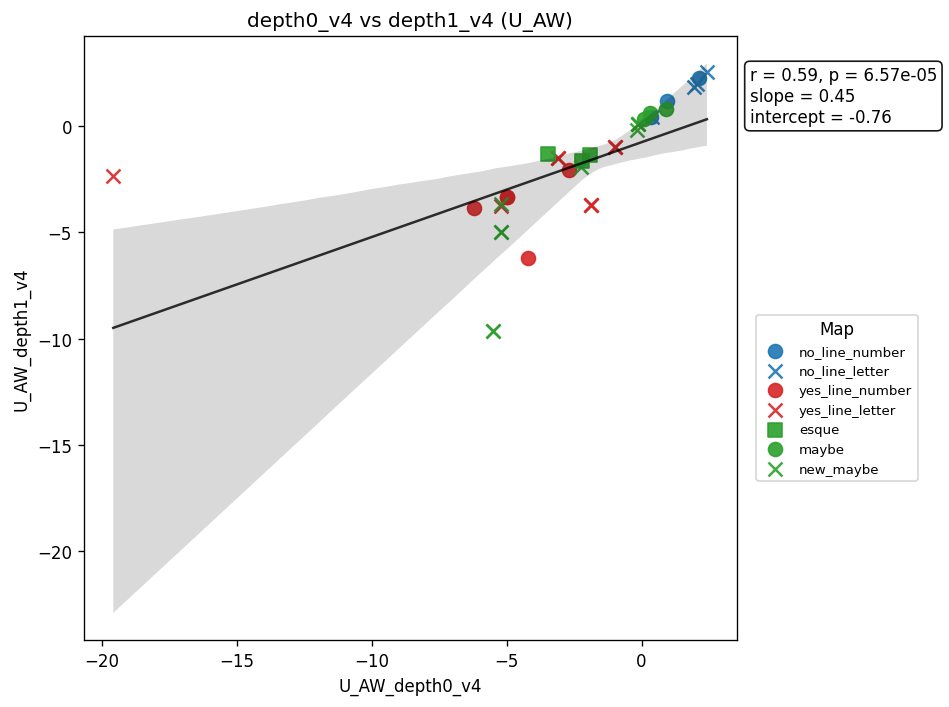

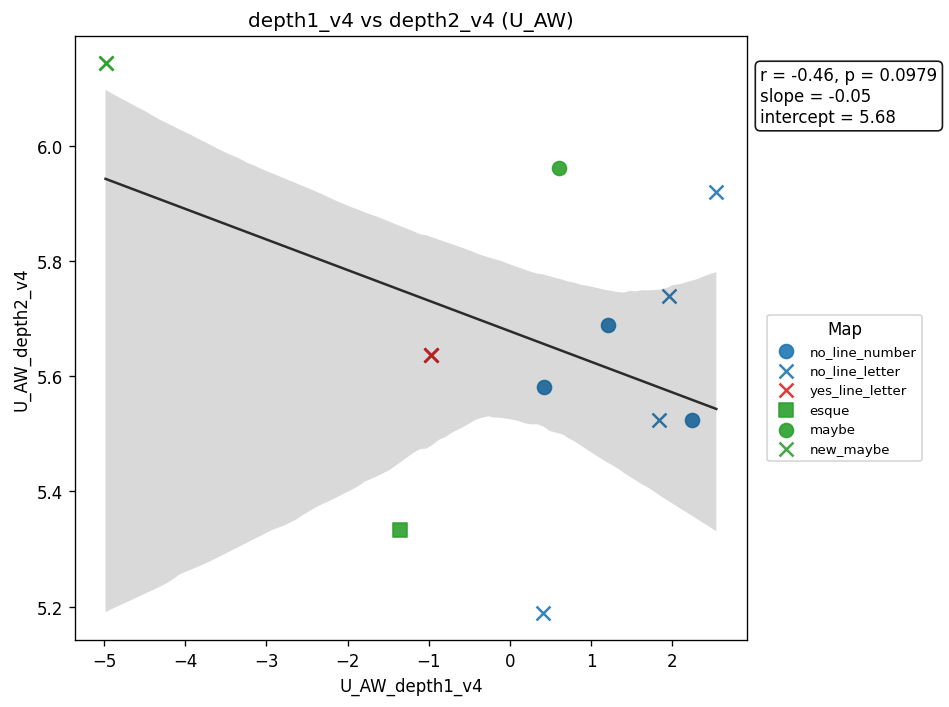

,blind_L0,blind_L1,depth0_v4,depth1_v4,depth2_v4
experiment,,,,,
Logan moral (pooled),0.233,0.589,0.278,0.461,-0.283
Joe univ,0.507,0.836,0.581,0.762,-0.349
Joe moral,0.204,0.653,0.264,0.561,-0.352


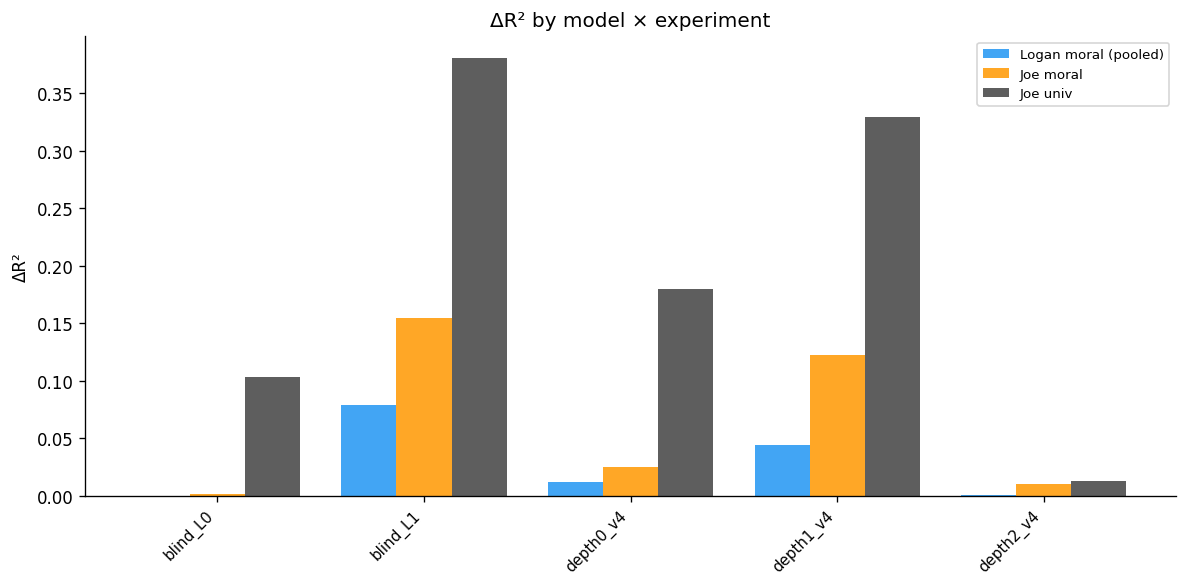

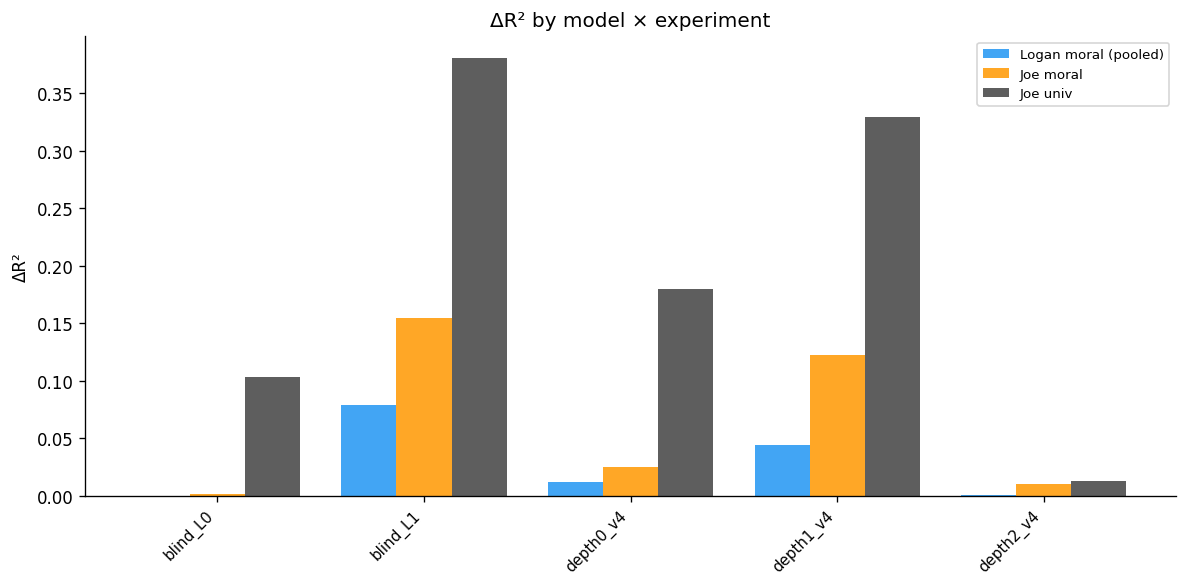

In [114]:
# =============================================================================
# CELL 1: depth1_v4 vs depth0_v4 scatter
# =============================================================================

a = dm['logan_moral']['depth0_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth0_v4'})
b = dm['logan_moral']['depth1_v4'][['stimulus', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth1_v4'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_depth0_v4', y_col='U_AW_depth1_v4',
                       title='depth0_v4 vs depth1_v4 (U_AW)',
                       save_path='figures/depth0_v4_vs_depth1_v4')

# =============================================================================
# CELL 2: depth2_v4 vs depth1_v4 scatter
# =============================================================================

a = dm['logan_moral']['depth1_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth1_v4'})
b = dm['logan_moral']['depth2_v4'][['stimulus', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth2_v4'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_depth1_v4', y_col='U_AW_depth2_v4',
                       title='depth1_v4 vs depth2_v4 (U_AW)',
                       save_path='figures/depth1_v4_vs_depth2_v4')

# =============================================================================
# CELL 3: Correlation table + ΔR² on v4 runs
# =============================================================================

RUN_ORDER_V4 = ['blind_L0', 'blind_L1', 'depth0_v4', 'depth1_v4', 'depth2_v4']
EXP_ORDER = [k for k in ['logan_moral', 'joe_univ', 'joe_moral'] if k in dm]

corr_v4, styled_v4 = correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER_V4,
    exp_order=EXP_ORDER,
)
display(styled_v4)
corr_v4.to_csv('figures/correlation_table_v4.csv')

eval_v4 = evaluate_fits_multi(dm, datasets)
keep_exps = ['Logan moral (pooled)', 'Joe moral', 'Joe univ']
eval_v4_filtered = eval_v4[eval_v4['experiment'].isin(keep_exps)]

plot_eval_multi(eval_v4_filtered, metric='delta_R2',
                run_order=RUN_ORDER_V4,
                save_path='figures/delta_r2_v4.png')

## 8. Per-map scatter plot

In [93]:
# UNIV

In [79]:
# testing new depth 2 vs depth 1

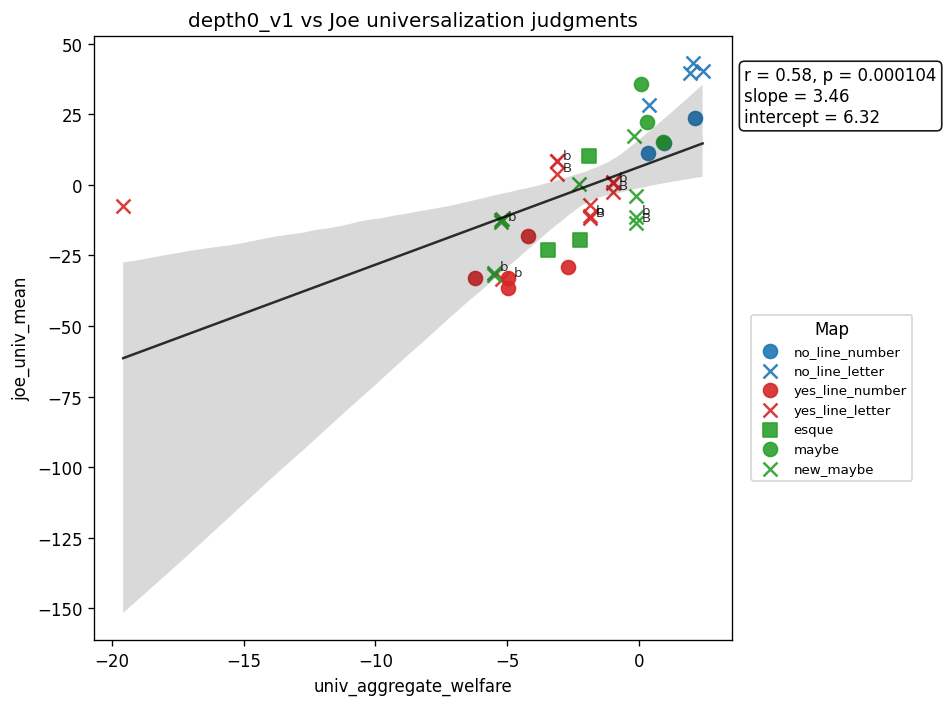

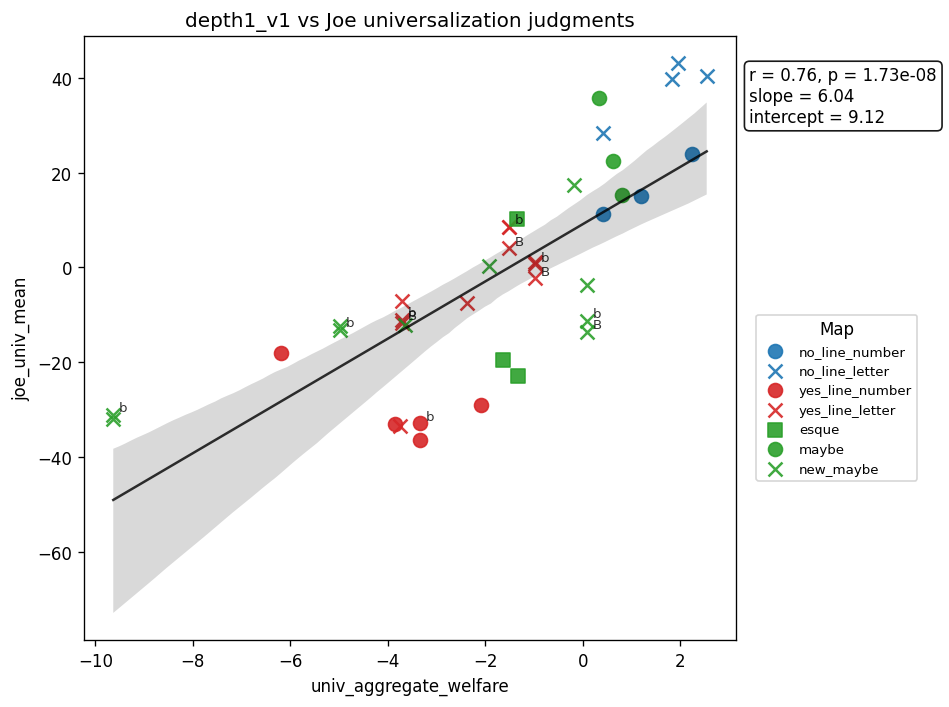

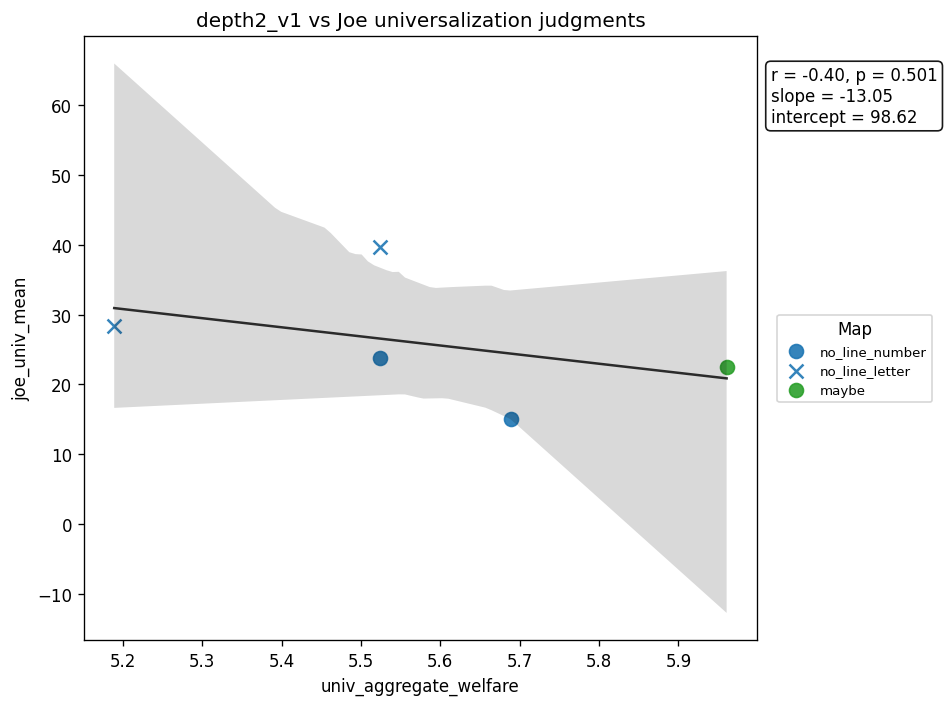

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v1 vs Joe universalization judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_univ_mean'>)

In [62]:
### V1
plot_simple_regression(dm['joe_univ']['depth0_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth0_v1 vs Joe universalization judgments',
                       display_condition=True,
                      save_path="figures/univ_vs_d0_v1")

plot_simple_regression(dm['joe_univ']['depth1_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth1_v1 vs Joe universalization judgments',
                       display_condition=True,
                        save_path="figures/univ_vs_d1_v1")

plot_simple_regression(dm['joe_univ']['depth2_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth2_v1 vs Joe universalization judgments',
                       display_condition=True,
                            save_path="figures/univ_vs_d2_v1")


In [ ]:
# MORAL

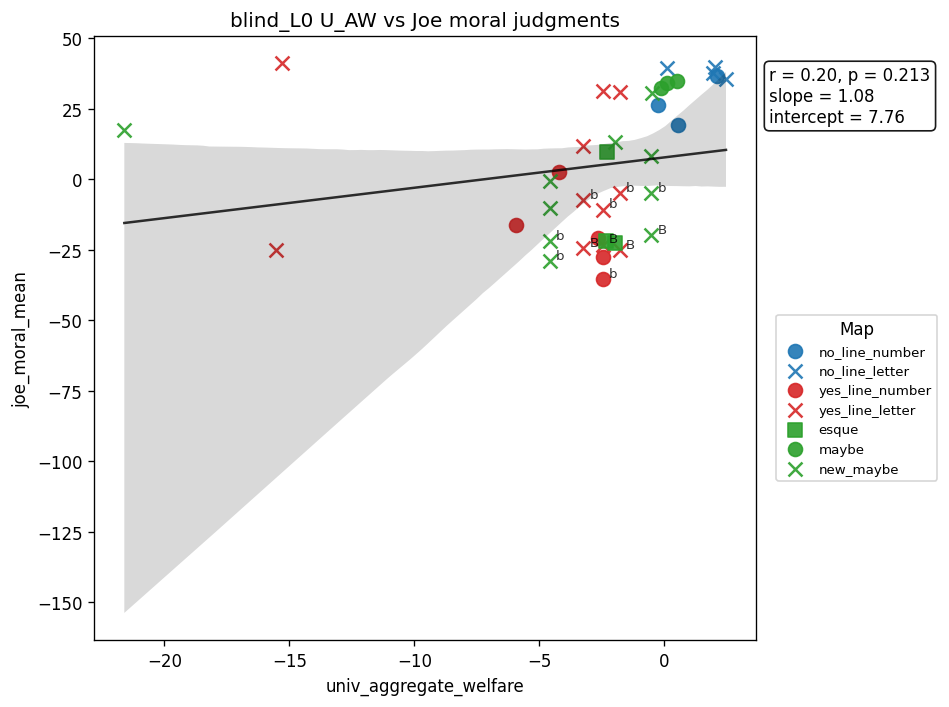

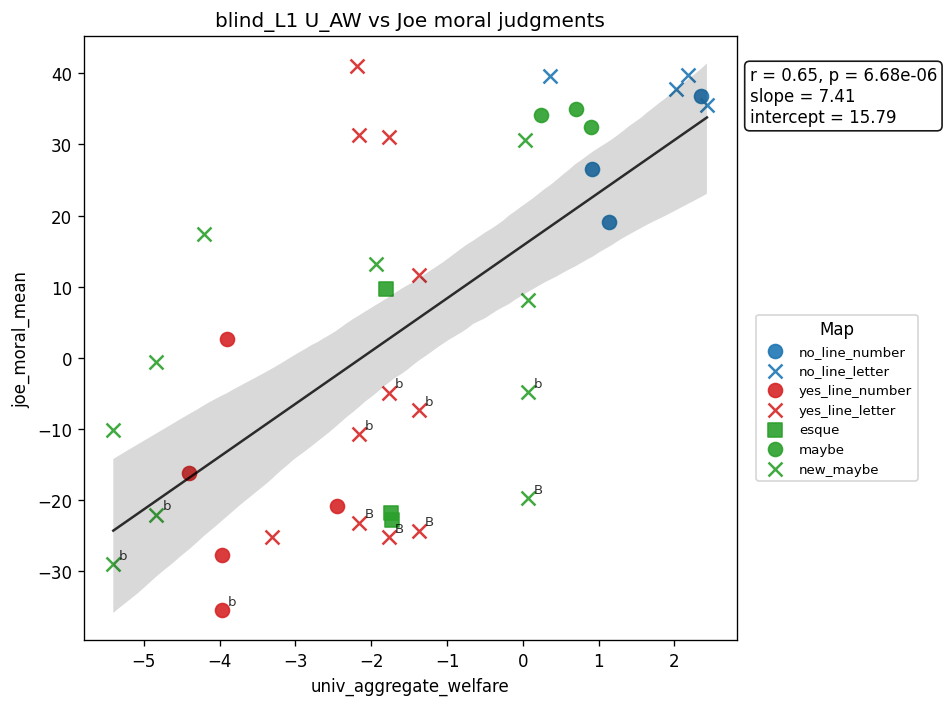

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'blind_L1 U_AW vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [31]:
### Baslines
plot_simple_regression(dm['joe_moral']['blind_L0'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='blind_L0 U_AW vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_blind_L0")

plot_simple_regression(dm['joe_moral']['blind_L1'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='blind_L1 U_AW vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_blind_L1")


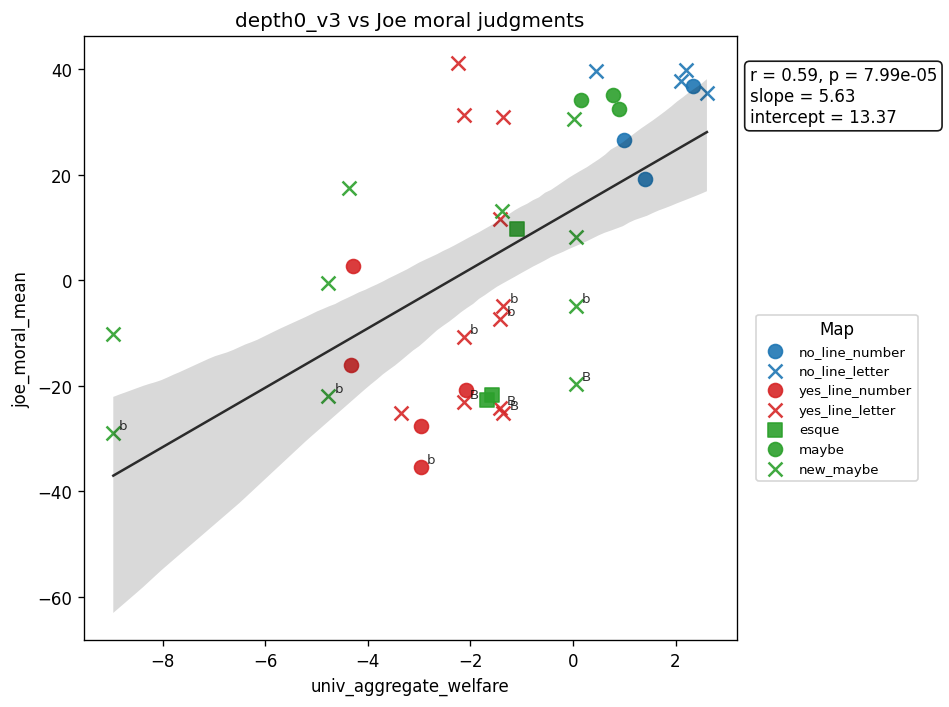

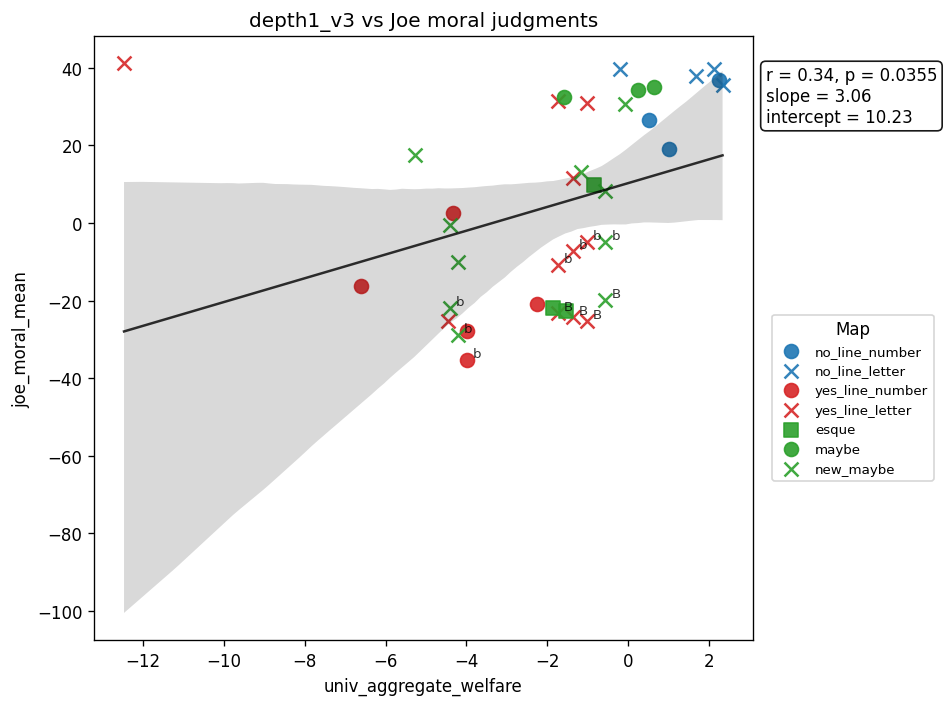

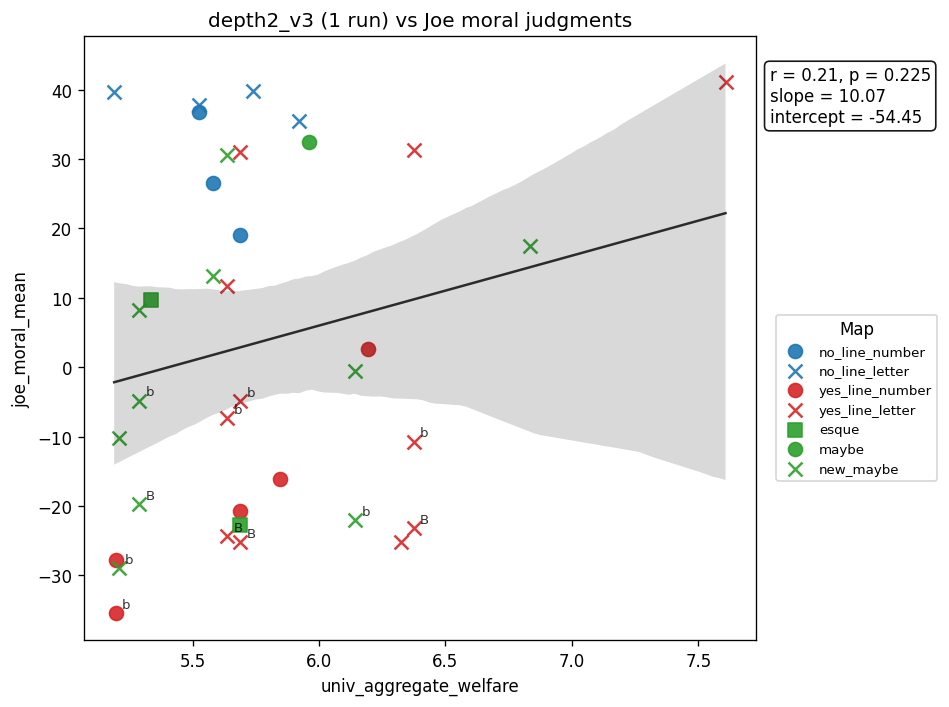

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v3 (1 run) vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [32]:
### V3
plot_simple_regression(dm['joe_moral']['depth0_v3'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v3 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v3")

plot_simple_regression(dm['joe_moral']['depth1_v3'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v3 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v3")

plot_simple_regression(dm['joe_moral']['depth2_v3_1run'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v3 (1 run) vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v3_1run")


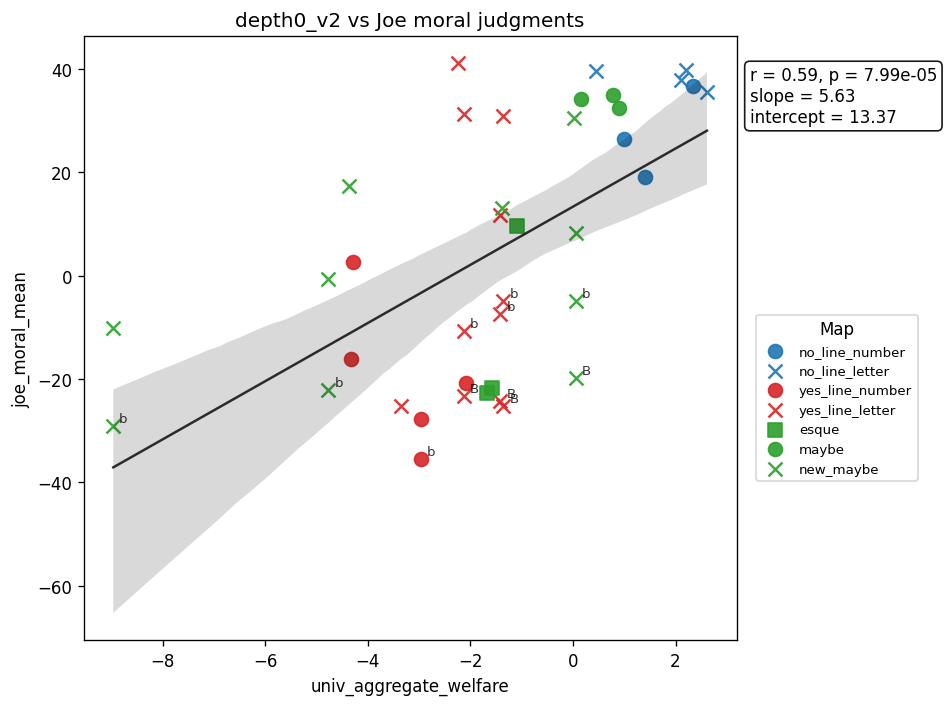

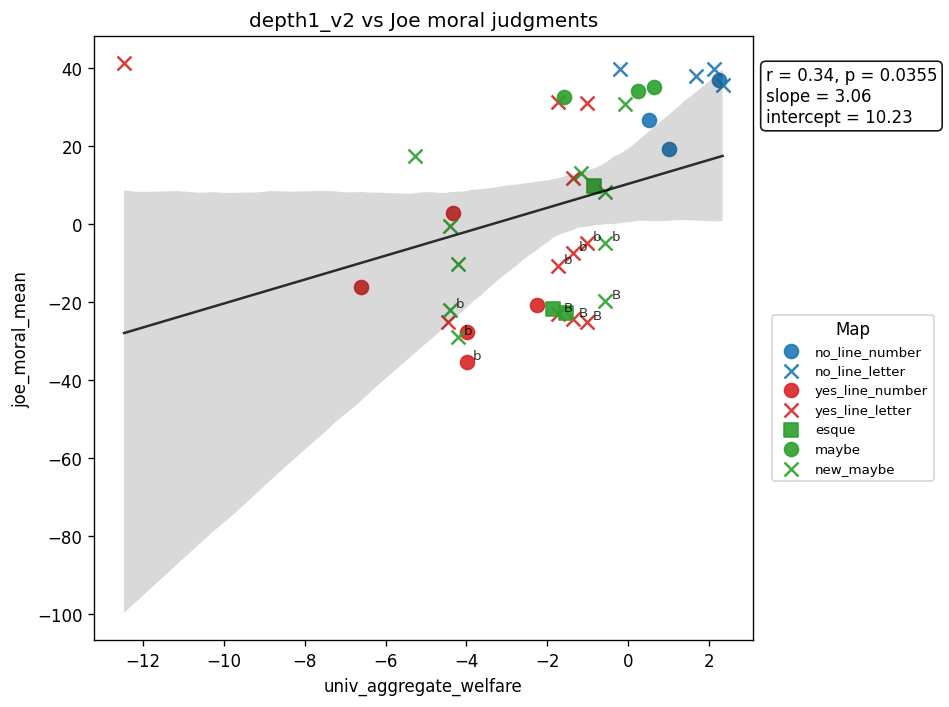

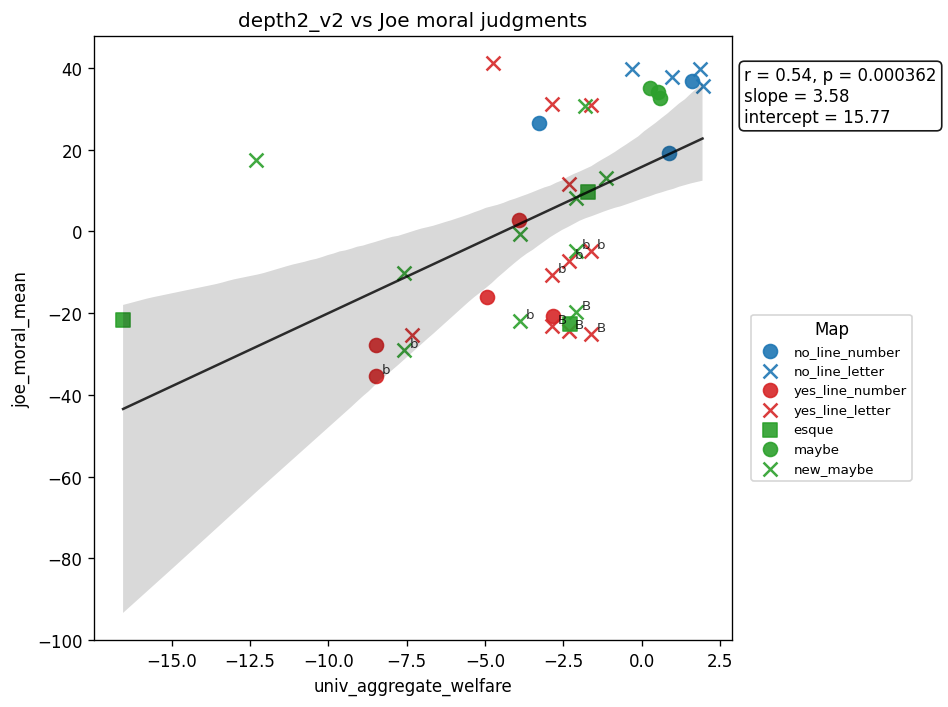

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v2 vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [34]:
### V2
plot_simple_regression(dm['joe_moral']['depth0_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v2 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v2")

plot_simple_regression(dm['joe_moral']['depth1_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v2 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v2")

plot_simple_regression(dm['joe_moral']['depth2_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v2 vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v2")


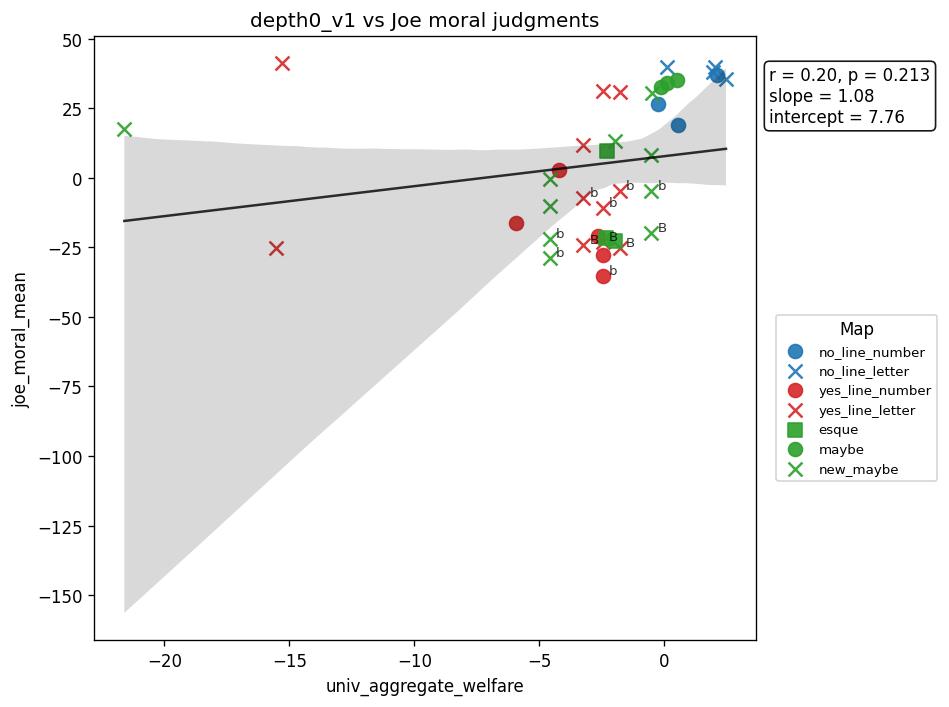

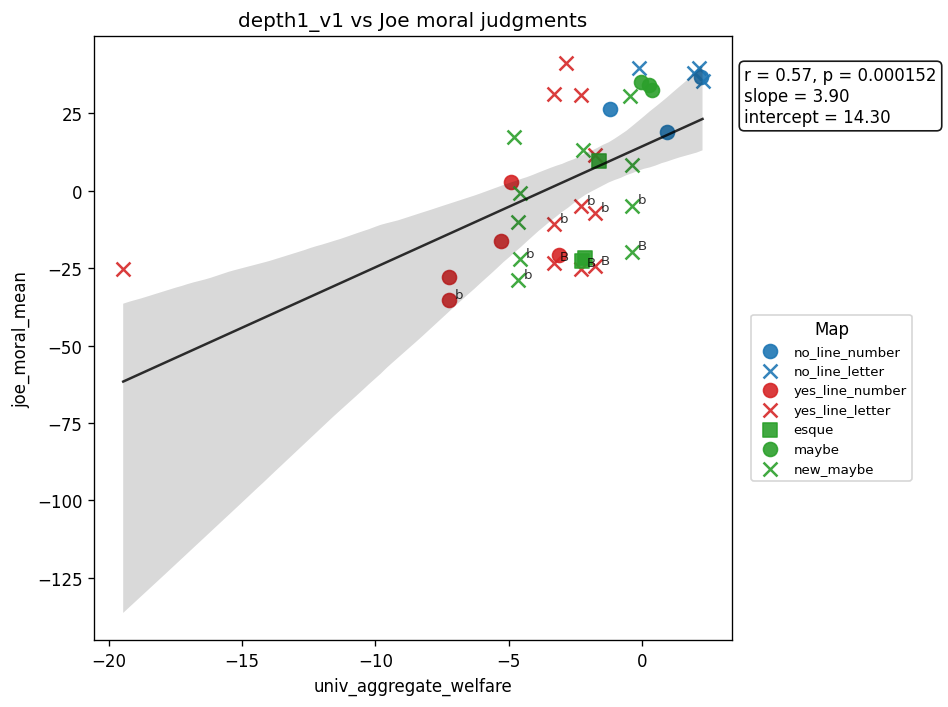

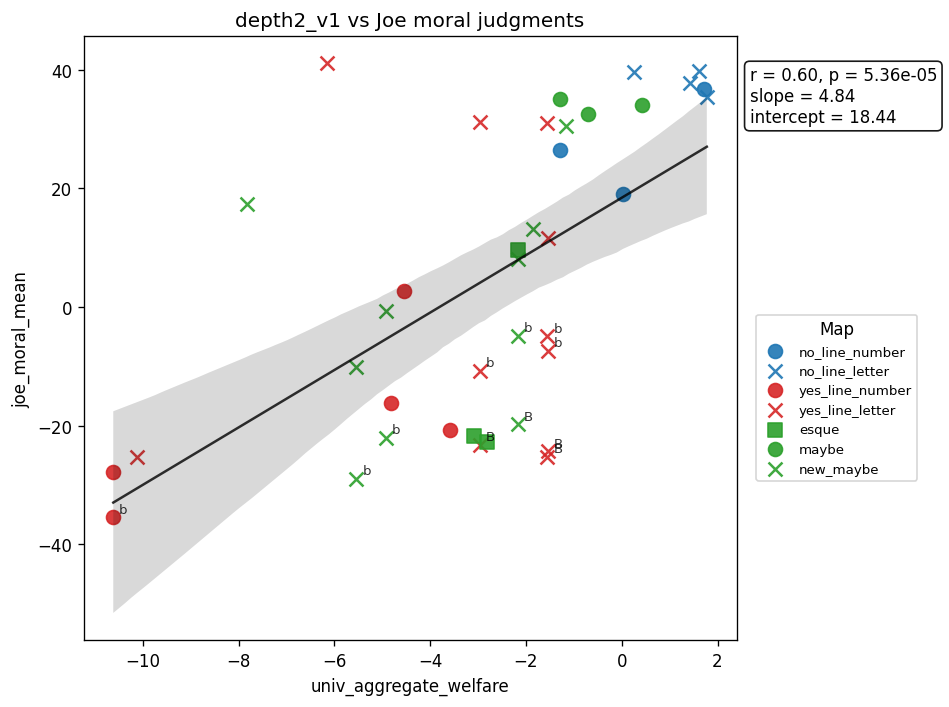

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v1 vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [35]:
### V1
plot_simple_regression(dm['joe_moral']['depth0'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v1 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v1")

plot_simple_regression(dm['joe_moral']['depth1'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v1 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v1")

plot_simple_regression(dm['joe_moral']['depth2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v1 vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v1")


In [81]:
a = dm['logan_moral']['depth0_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_blind_L1'})
b = dm['logan_moral']['depth1_v4'][['stimulus', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_depth0_v2'})
merged = a.merge(b, on='stimulus')
 
plot_simple_regression(merged, x_col='U_AW_depth0_v4', y_col='U_AW_depth1_v4',
                       title='depth0_v4 vs depth1_v4', save_path="depth1_vs_0")

KeyError: ['U_AW_depth0_v4', 'U_AW_depth1_v4']

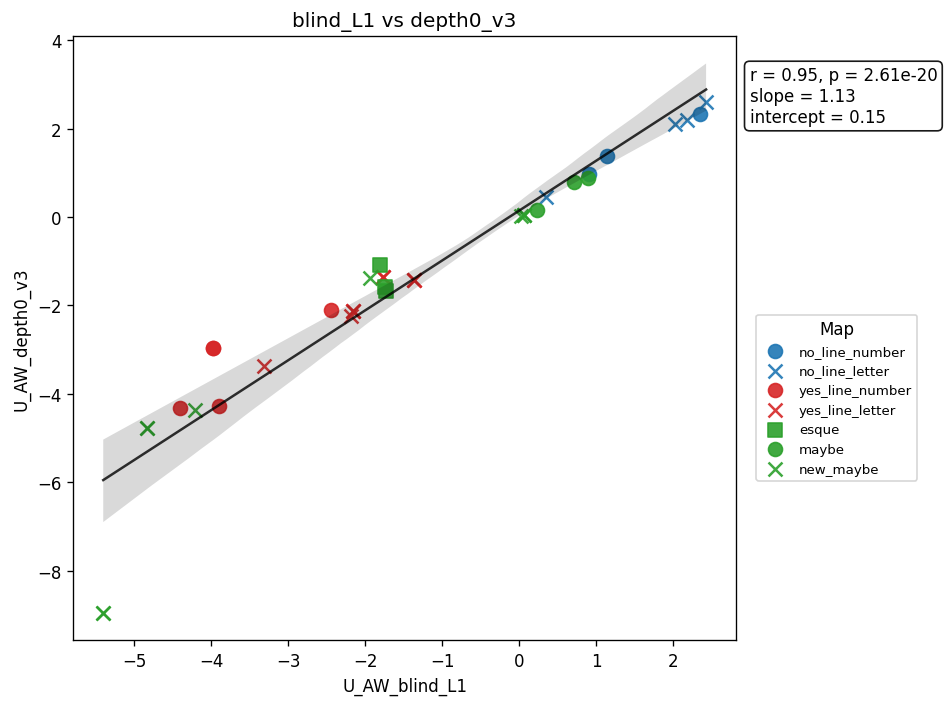

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'blind_L1 vs depth0_v3'}, xlabel='U_AW_blind_L1', ylabel='U_AW_depth0_v3'>)

In [29]:
a = dm['logan_moral']['blind_L1'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_blind_L1'})
b = dm['logan_moral']['depth0_v3'][['stimulus', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_depth0_v3'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_blind_L1', y_col='U_AW_depth0_v3',
                       title='blind_L1 vs depth0_v3', save_path="blind_L1_vs_depth0_v3")

In [17]:
pairs = [
    ("blind_L0", "depth0_v3"),      
    ("depth0_v3", "depth1_v3"),      
    ("depth0_v3", "depth2_v3_1run"),   
    ("depth1_v3", "depth2_v3_1run"),        
]

for tx, ty in pairs:
    if tx in univ_summaries and ty in univ_summaries:
        fig = scatter_two_models(univ_summaries, tx, ty)
        fig.savefig(f"figures/{tx}_vs_{ty}_scatter.png", dpi=150, bbox_inches="tight")
        plt.show()

NameError: name 'univ_summaries' is not defined